# Exploratory Data Analysis: Anime Recommendation Database 2020

**Dataset**: [Kaggle - Anime Recommendation Database 2020](https://www.kaggle.com/datasets/hernan4444/anime-recommendation-database-2020)

This notebook performs a thorough EDA on two core files:
- **anime.csv** — metadata for 17,562 anime (scores, genres, type, episodes, etc.)
- **animelist.csv** — ~109M user-anime interactions (ratings, watching status, episodes watched)

The goal is to understand the data deeply before building recommendation systems.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Loading and Initial Inspection

### 1.1 anime.csv

In [4]:
anime = pd.read_csv('anime.csv')
print(f"Shape: {anime.shape}")
print(f"\nColumn dtypes:\n{anime.dtypes}")
anime.head(3)

Shape: (17562, 35)

Column dtypes:
MAL_ID            int64
Name             object
Score            object
Genres           object
English name     object
Japanese name    object
Type             object
Episodes         object
Aired            object
Premiered        object
Producers        object
Licensors        object
Studios          object
Source           object
Duration         object
Rating           object
Ranked           object
Popularity        int64
Members           int64
Favorites         int64
Watching          int64
Completed         int64
On-Hold           int64
Dropped           int64
Plan to Watch     int64
Score-10         object
Score-9          object
Score-8          object
Score-7          object
Score-6          object
Score-5          object
Score-4          object
Score-3          object
Score-2          object
Score-1          object
dtype: object


,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,...,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0


In [5]:
anime.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MAL_ID,17562.0,NaN,NaN,NaN,21477.192347,14900.09317,1.0,5953.5,22820.0,35624.75,48492.0
Name,17562,17558,Maou Gakuin no Futekigousha: Shijou Saikyou no...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Score,17562,533,Unknown,5141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,17562,5034,Hentai,969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
English name,17562,6831,Unknown,10565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Japanese name,17562,16679,Unknown,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,17562,7,TV,4996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Episodes,17562,201,1,8381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aired,17562,11947,Unknown,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Premiered,17562,231,Unknown,12817,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 animelist.csv

Since animelist.csv has ~109M rows, we load it in chunks to get summary statistics, then work with a random sample of 5,000 users for detailed analysis.

In [6]:
# First pass: get basic stats via chunked reading
chunk_size = 5_000_000
total_rows = 0
rating_counts = Counter()
status_counts = Counter()
unique_users = set()
unique_animes = set()
rating_sum = 0
rating_nonzero_count = 0
zero_rating_count = 0

for chunk in pd.read_csv('animelist.csv', chunksize=chunk_size):
    total_rows += len(chunk)
    unique_users.update(chunk['user_id'].unique())
    unique_animes.update(chunk['anime_id'].unique())

    # Rating distribution (0 means "not rated" in this dataset)
    rc = chunk['rating'].value_counts()
    for val, cnt in rc.items():
        rating_counts[val] += cnt

    # Watching status distribution
    sc = chunk['watching_status'].value_counts()
    for val, cnt in sc.items():
        status_counts[val] += cnt

    # Stats for non-zero ratings
    nonzero = chunk[chunk['rating'] > 0]['rating']
    rating_sum += nonzero.sum()
    rating_nonzero_count += len(nonzero)
    zero_rating_count += (chunk['rating'] == 0).sum()

print(f"Total interactions: {total_rows:,}")
print(f"Unique users: {len(unique_users):,}")
print(f"Unique anime: {len(unique_animes):,}")
print(f"\nRated interactions (rating > 0): {rating_nonzero_count:,} ({rating_nonzero_count/total_rows*100:.1f}%)")
print(f"Unrated interactions (rating = 0): {zero_rating_count:,} ({zero_rating_count/total_rows*100:.1f}%)")
print(f"Mean rating (excl. 0): {rating_sum/rating_nonzero_count:.2f}")

Total interactions: 109,224,747
Unique users: 325,770
Unique anime: 17,562

Rated interactions (rating > 0): 62,397,712 (57.1%)
Unrated interactions (rating = 0): 46,827,035 (42.9%)
Mean rating (excl. 0): 7.43


In [7]:
# Calculate sparsity of the user-item matrix
n_users = len(unique_users)
n_animes = len(unique_animes)
possible_interactions = n_users * n_animes
sparsity = 1 - (total_rows / possible_interactions)

print(f"User-Item Matrix Dimensions: {n_users:,} users x {n_animes:,} anime")
print(f"Possible interactions: {possible_interactions:,.0f}")
print(f"Actual interactions: {total_rows:,}")
print(f"Sparsity: {sparsity*100:.4f}%")
print(f"\nIf we only consider rated interactions (rating > 0):")
sparsity_rated = 1 - (rating_nonzero_count / possible_interactions)
print(f"Sparsity: {sparsity_rated*100:.4f}%")

User-Item Matrix Dimensions: 325,770 users x 17,562 anime
Possible interactions: 5,721,172,740
Actual interactions: 109,224,747
Sparsity: 98.0909%

If we only consider rated interactions (rating > 0):
Sparsity: 98.9094%


In [8]:
# Load a sample of animelist for detailed analysis (sample 5,000 random users)
np.random.seed(42)
sampled_users = np.random.choice(list(unique_users), size=min(5000, len(unique_users)), replace=False)
sampled_users_set = set(sampled_users)

animelist_sample = []
for chunk in pd.read_csv('animelist.csv', chunksize=chunk_size):
    mask = chunk['user_id'].isin(sampled_users_set)
    animelist_sample.append(chunk[mask])

animelist_sample = pd.concat(animelist_sample, ignore_index=True)
print(f"Sampled animelist shape: {animelist_sample.shape}")
print(f"Sampled users: {animelist_sample['user_id'].nunique():,}")
print(f"Sampled anime: {animelist_sample['anime_id'].nunique():,}")
animelist_sample.head()

Sampled animelist shape: (1663415, 5)
Sampled users: 5,000
Sampled anime: 17,108


,user_id,anime_id,rating,watching_status,watched_episodes
0,7,26349,8,1,8
1,7,23251,9,1,0
2,7,14753,7,1,2
3,7,23755,0,1,14
4,7,6682,6,2,12


---
## 2. EDA on anime.csv

### 2.1 Missing Values Analysis

Columns with missing/unknown values: 25 out of 35

               NaN Count  Unknown Count  Total Missing  Missing %
Licensors              0          13616          13616      77.53
Premiered              0          12817          12817      72.98
English name           0          10565          10565      60.16
Producers              0           7794           7794      44.38
Studios                0           7079           7079      40.31
Score                  0           5141           5141      29.27
Source                 0           3567           3567      20.31
Score-9                0           3167           3167      18.03
Ranked                 0           1762           1762      10.03
Score-2                0           1597           1597       9.09
Score-8                0           1371           1371       7.81
Score-3                0           1307           1307       7.44
Score-4                0            977            977       5.56
Rating                 0 

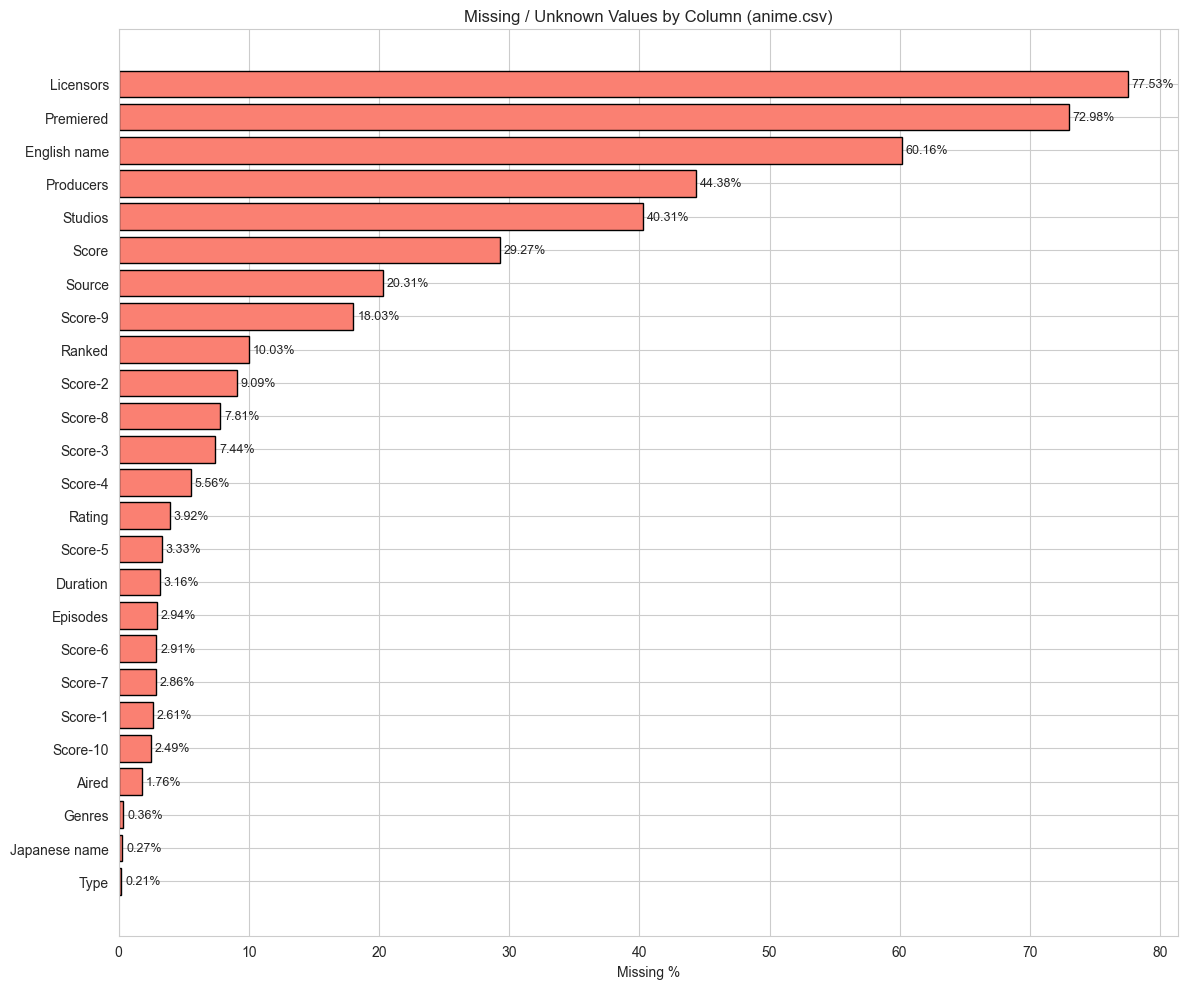

In [9]:
# Missing values analysis — including "Unknown" placeholders as missing
# Many columns use "Unknown" instead of NaN
unknown_counts = anime.apply(lambda col: col.astype(str).str.strip().isin(['Unknown', 'unknown', 'UNKNOWN', '']).sum())
null_counts = anime.isnull().sum()
combined_missing = null_counts + unknown_counts
combined_pct = (combined_missing / len(anime) * 100).round(2)

missing_df = pd.DataFrame({
    'NaN Count': null_counts,
    'Unknown Count': unknown_counts,
    'Total Missing': combined_missing,
    'Missing %': combined_pct
})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values('Missing %', ascending=False)

print(f"Columns with missing/unknown values: {len(missing_df)} out of {len(anime.columns)}\n")
print(missing_df.to_string())

# Visualize
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(3, len(missing_df) * 0.4)))
    bars = ax.barh(range(len(missing_df)), missing_df['Missing %'], color='salmon', edgecolor='black')
    ax.set_yticks(range(len(missing_df)))
    ax.set_yticklabels(missing_df.index)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing / Unknown Values by Column (anime.csv)')
    ax.invert_yaxis()
    for i, v in enumerate(missing_df['Missing %']):
        ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing or unknown values found.")


### 2.2 Anime Type Distribution

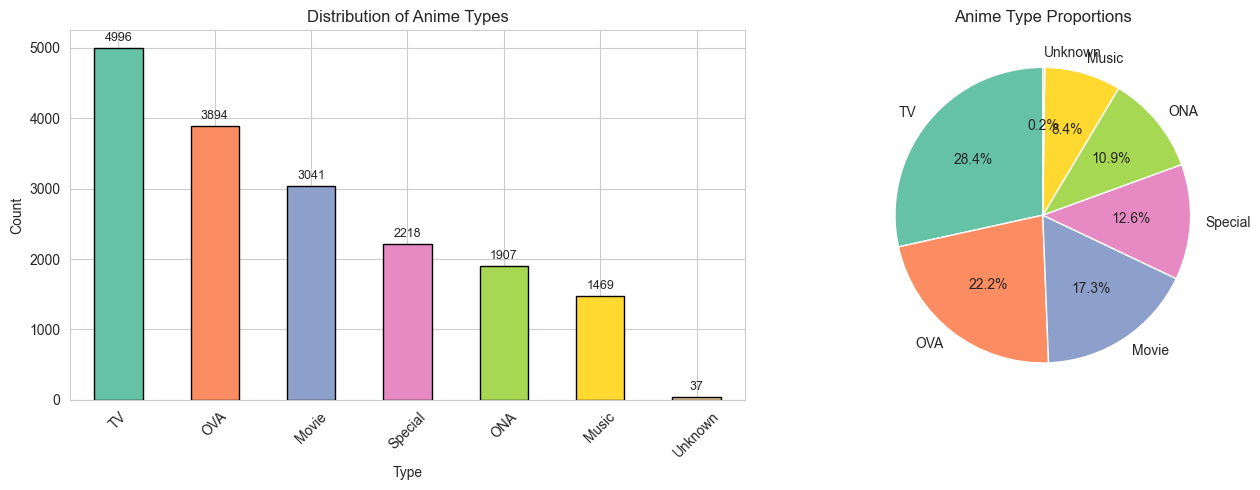


Type breakdown:
TV         4996
OVA        3894
Movie      3041
Special    2218
ONA        1907
Music      1469
Unknown      37
Name: Type, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type distribution
type_counts = anime['Type'].value_counts()
colors = sns.color_palette('Set2', len(type_counts))
type_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Anime Types')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(type_counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

# Type as pie chart
type_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Anime Type Proportions')

plt.tight_layout()
plt.show()

print(f"\nType breakdown:\n{type_counts}")

### 2.3 Score Distribution

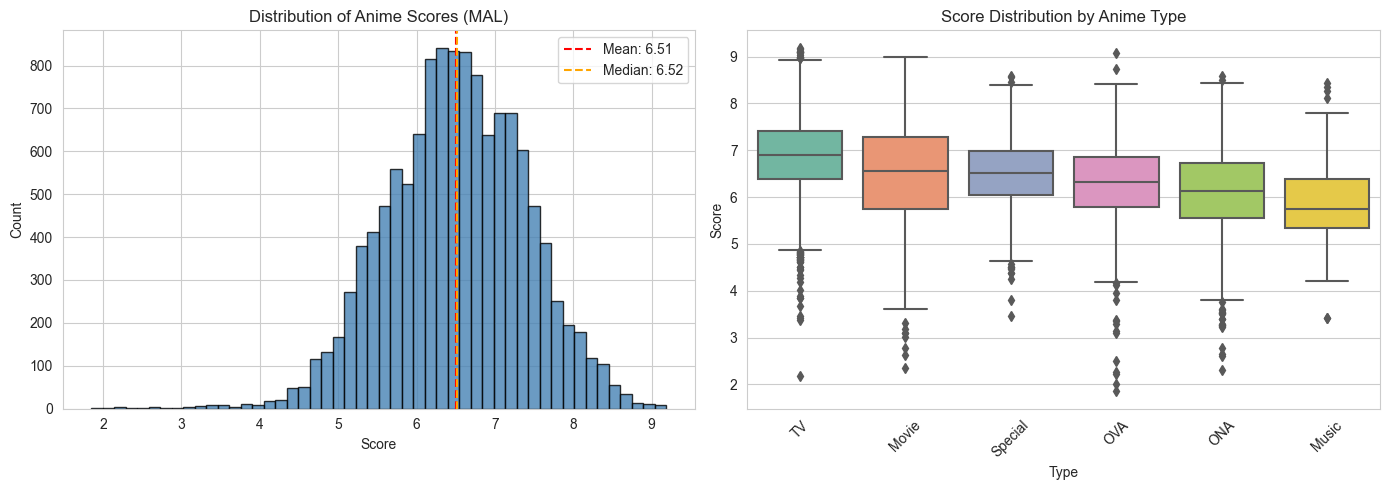


Score statistics:
count    12421.000000
mean         6.509999
std          0.886717
min          1.850000
25%          5.930000
50%          6.520000
75%          7.140000
max          9.190000
Name: Score, dtype: float64

Anime without a score: 5141


In [11]:
# Convert Score to numeric (some may be 'Unknown')
anime['Score'] = pd.to_numeric(anime['Score'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scores
anime['Score'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(anime['Score'].mean(), color='red', linestyle='--', label=f"Mean: {anime['Score'].mean():.2f}")
axes[0].axvline(anime['Score'].median(), color='orange', linestyle='--', label=f"Median: {anime['Score'].median():.2f}")
axes[0].set_title('Distribution of Anime Scores (MAL)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot by type
scored_anime = anime.dropna(subset=['Score', 'Type'])
type_order = scored_anime.groupby('Type')['Score'].median().sort_values(ascending=False).index
sns.boxplot(data=scored_anime, x='Type', y='Score', order=type_order, ax=axes[1], palette='Set2')
axes[1].set_title('Score Distribution by Anime Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nScore statistics:\n{anime['Score'].describe()}")
print(f"\nAnime without a score: {anime['Score'].isna().sum()}")

### 2.4 Genre Analysis

Total unique genres: 44



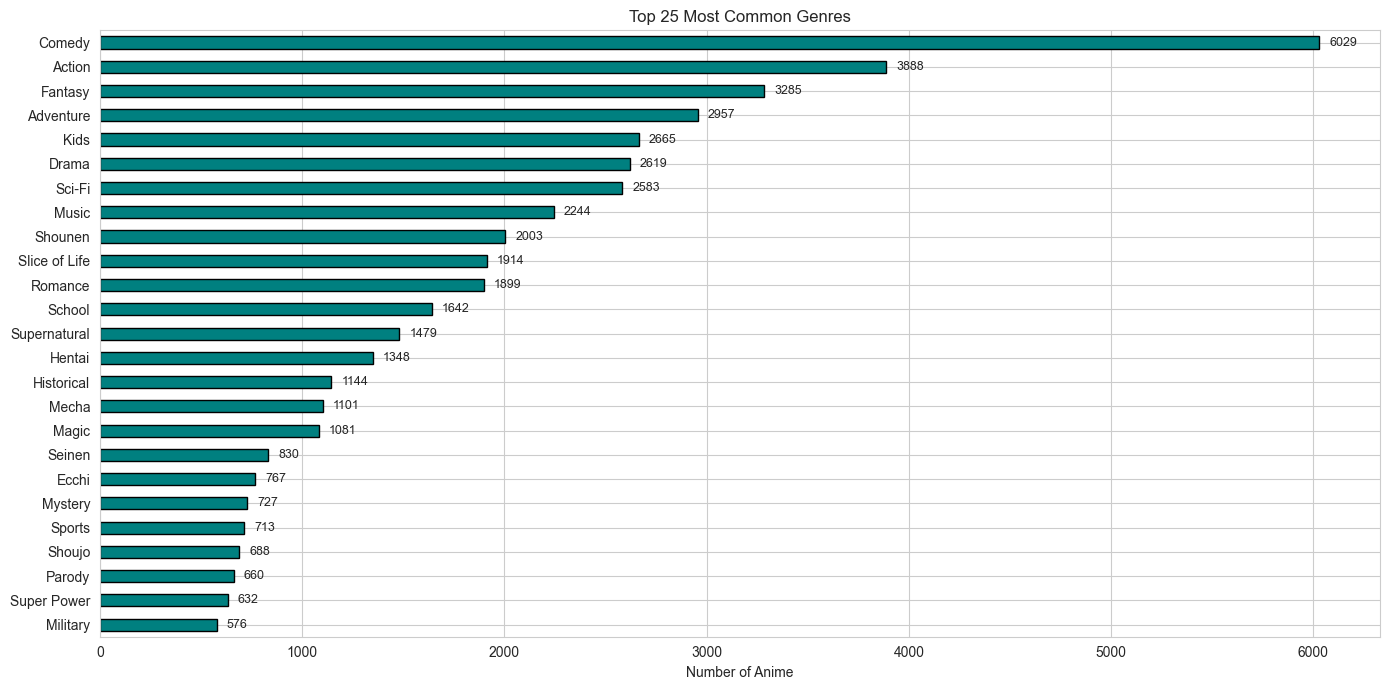

In [12]:
# Explode genres (comma-separated)
genre_series = anime['Genres'].dropna().str.split(', ').explode().str.strip()
genre_counts = genre_series.value_counts()

print(f"Total unique genres: {len(genre_counts)}\n")

fig, ax = plt.subplots(figsize=(14, 7))
genre_counts.head(25).plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Number of Anime')
ax.set_title('Top 25 Most Common Genres')
ax.invert_yaxis()
for i, v in enumerate(genre_counts.head(25)):
    ax.text(v + 50, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

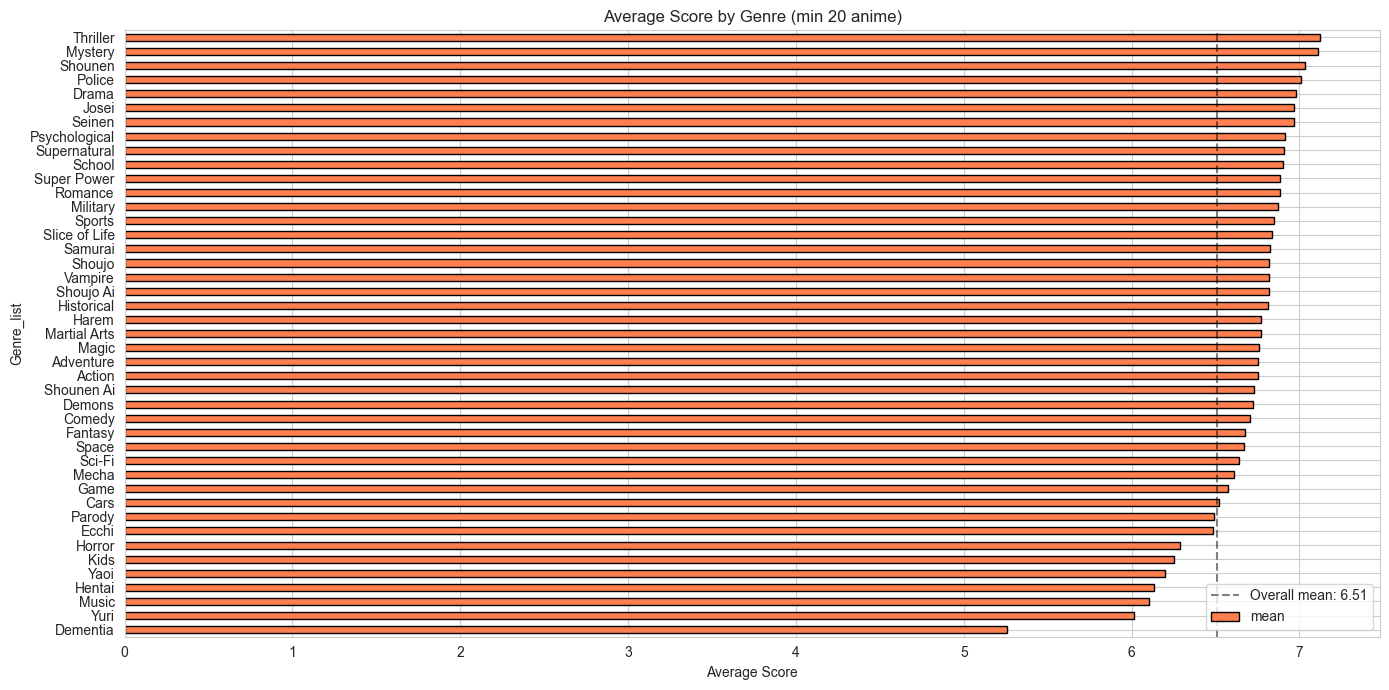

In [13]:
# Average score by genre
anime_exploded = anime.dropna(subset=['Genres', 'Score']).copy()
anime_exploded['Genre_list'] = anime_exploded['Genres'].str.split(', ')
anime_exploded = anime_exploded.explode('Genre_list')
anime_exploded['Genre_list'] = anime_exploded['Genre_list'].str.strip()

genre_scores = anime_exploded.groupby('Genre_list')['Score'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
genre_scores = genre_scores[genre_scores['count'] >= 20]  # filter genres with few entries

fig, ax = plt.subplots(figsize=(14, 7))
genre_scores['mean'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Average Score')
ax.set_title('Average Score by Genre (min 20 anime)')
ax.invert_yaxis()
ax.axvline(anime['Score'].mean(), color='black', linestyle='--', alpha=0.5, label=f"Overall mean: {anime['Score'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

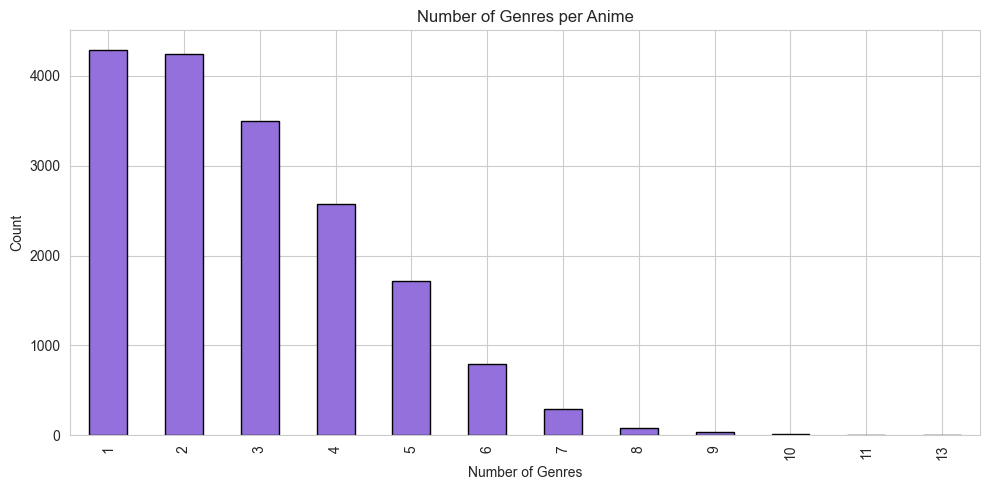

Average genres per anime: 2.86
Max genres: 13


In [14]:
# Number of genres per anime
anime['n_genres'] = anime['Genres'].fillna('').apply(lambda x: len([g for g in x.split(', ') if g.strip()]) if x else 0)

fig, ax = plt.subplots(figsize=(10, 5))
anime['n_genres'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Number of Genres per Anime')
ax.set_xlabel('Number of Genres')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Average genres per anime: {anime['n_genres'].mean():.2f}")
print(f"Max genres: {anime['n_genres'].max()}")

### 2.5 Episodes Distribution

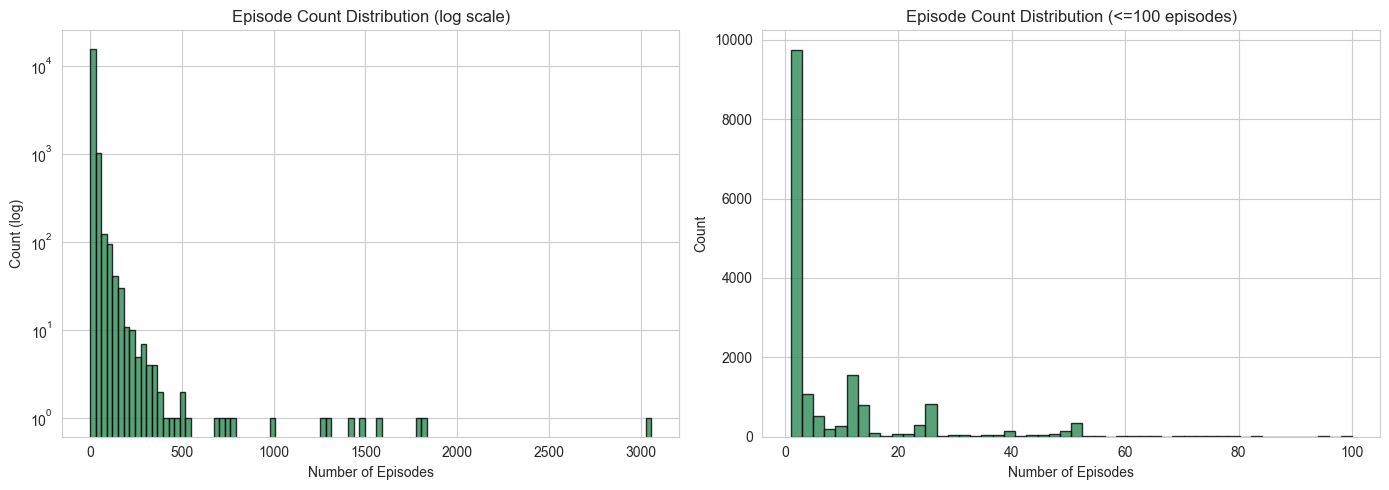


Episode statistics:
count    17046.000000
mean        11.525519
std         47.348640
min          1.000000
25%          1.000000
50%          2.000000
75%         12.000000
max       3057.000000
Name: Episodes, dtype: float64

Top 10 longest anime:
                                 Name Type  Episodes  Score
                              Lan Mao   TV    3057.0    NaN
                           Oyako Club   TV    1818.0   5.60
                      Doraemon (1979)   TV    1787.0   7.70
               Kirin Monoshiri Yakata   TV    1565.0   5.82
   Manga Nippon Mukashibanashi (1976)   TV    1471.0   6.00
                     Hoka Hoka Kazoku   TV    1428.0   5.80
             Kirin Ashita no Calendar   TV    1306.0    NaN
Monoshiri Daigaku: Ashita no Calendar   TV    1274.0   5.77
                Sekai Monoshiri Ryoko   TV    1006.0   5.68
                       Kotowaza House   TV     773.0    NaN


In [15]:
anime['Episodes'] = pd.to_numeric(anime['Episodes'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (log scale)
anime['Episodes'].dropna().hist(bins=100, ax=axes[0], color='seagreen', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Episode Count Distribution (log scale)')
axes[0].set_xlabel('Number of Episodes')
axes[0].set_ylabel('Count (log)')

# Zoomed in (<=100 episodes)
anime[anime['Episodes'] <= 100]['Episodes'].dropna().hist(bins=50, ax=axes[1], color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Episode Count Distribution (<=100 episodes)')
axes[1].set_xlabel('Number of Episodes')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nEpisode statistics:\n{anime['Episodes'].describe()}")
print(f"\nTop 10 longest anime:")
print(anime.nlargest(10, 'Episodes')[['Name', 'Type', 'Episodes', 'Score']].to_string(index=False))

### 2.6 Source Material & Age Rating Distribution

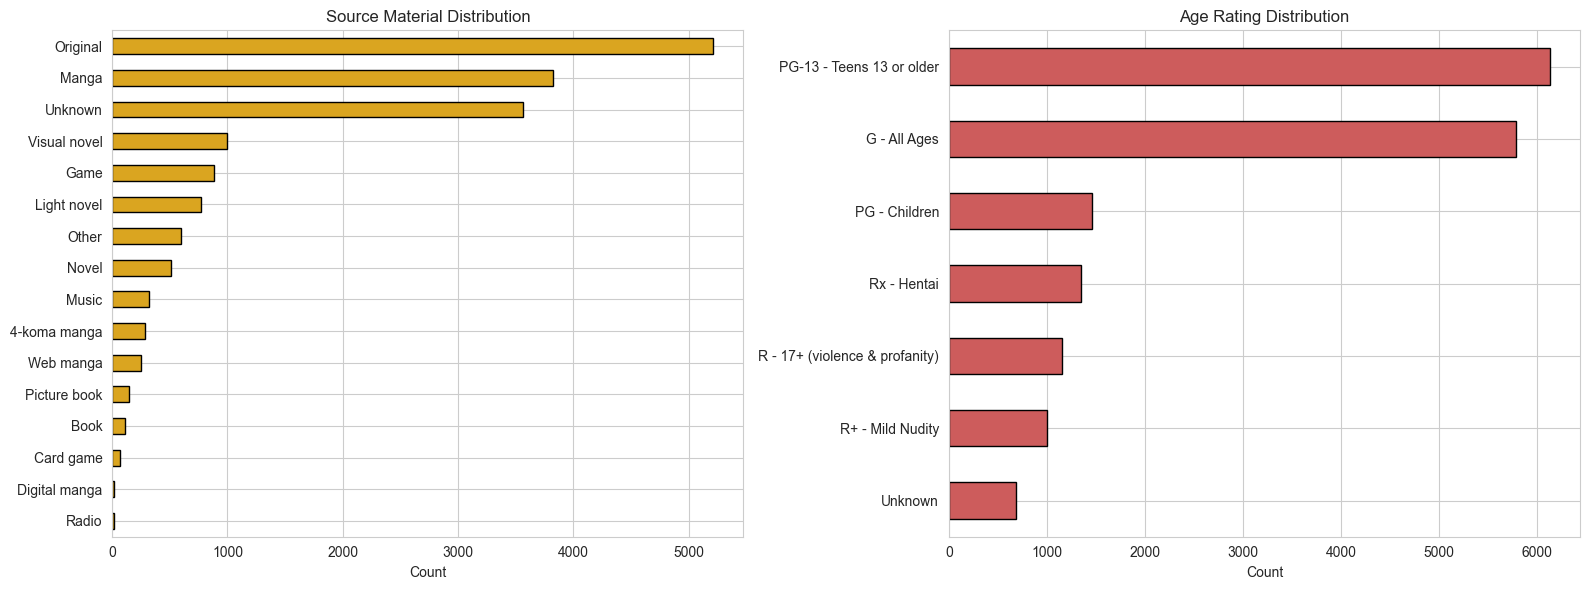

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Source material
source_counts = anime['Source'].value_counts()
source_counts.plot(kind='barh', ax=axes[0], color='goldenrod', edgecolor='black')
axes[0].set_title('Source Material Distribution')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Age Rating
rating_counts_anime = anime['Rating'].value_counts()
rating_counts_anime.plot(kind='barh', ax=axes[1], color='indianred', edgecolor='black')
axes[1].set_title('Age Rating Distribution')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 2.7 Popularity & Community Engagement

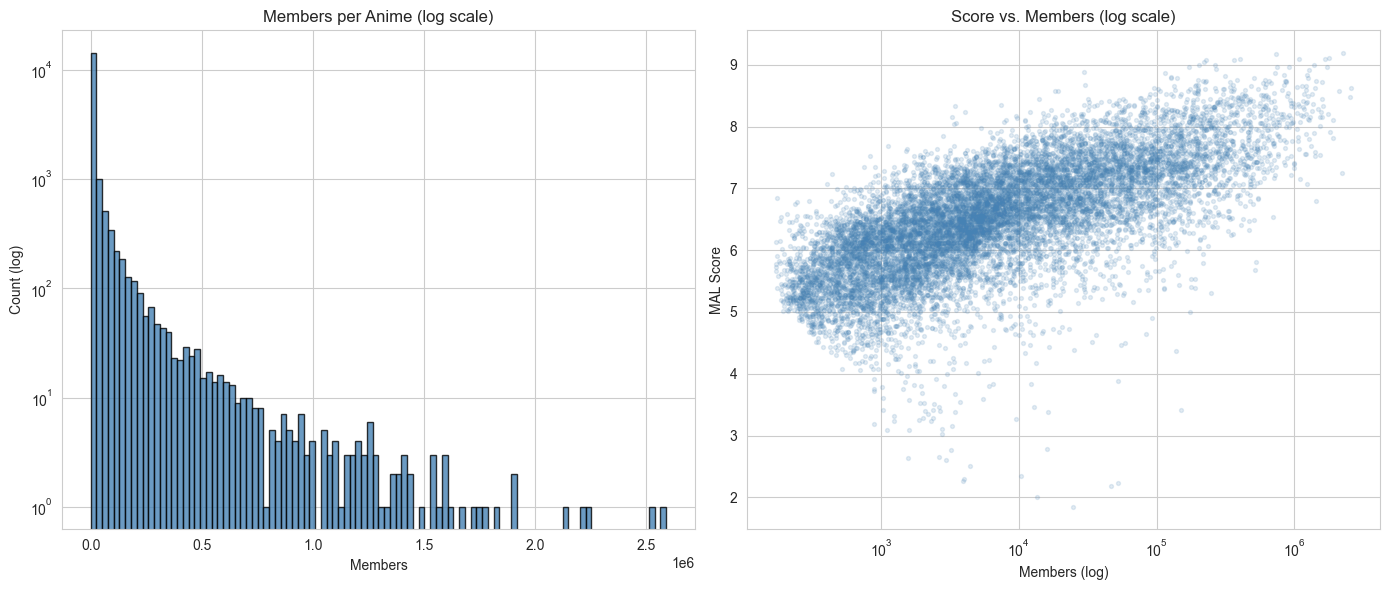

Correlation (Score vs log(Members)): 0.699

Top 10 most popular anime:
                            Name Type  Members  Score  Favorites
                      Death Note   TV  2589552   8.63     145201
              Shingeki no Kyojin   TV  2531397   8.48     129844
Fullmetal Alchemist: Brotherhood   TV  2248456   9.19     183914
                Sword Art Online   TV  2214395   7.25      66342
                   One Punch Man   TV  2123866   8.57      54435
           Boku no Hero Academia   TV  1909814   8.11      50005
                     Tokyo Ghoul   TV  1895488   7.81      45519
                          Naruto   TV  1830540   7.91      65586
                     Steins;Gate   TV  1771162   9.11     148452
                 No Game No Life   TV  1751054   8.20      45990


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Members distribution (log scale)
anime['Members'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.8, log=True)
axes[0].set_title('Members per Anime (log scale)')
axes[0].set_xlabel('Members')
axes[0].set_ylabel('Count (log)')

# Score vs Members (log x-axis)
scored = anime.dropna(subset=['Score'])
axes[1].scatter(scored['Members'], scored['Score'], alpha=0.15, s=8, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_title('Score vs. Members (log scale)')
axes[1].set_xlabel('Members (log)')
axes[1].set_ylabel('MAL Score')

plt.tight_layout()
plt.show()

print(f"Correlation (Score vs log(Members)): {scored['Score'].corr(np.log1p(scored['Members'])):.3f}")
print(f"\nTop 10 most popular anime:")
print(anime.nlargest(10, 'Members')[['Name', 'Type', 'Members', 'Score', 'Favorites']].to_string(index=False))

### 2.8 Score Breakdown Analysis (Score-1 through Score-10 columns)

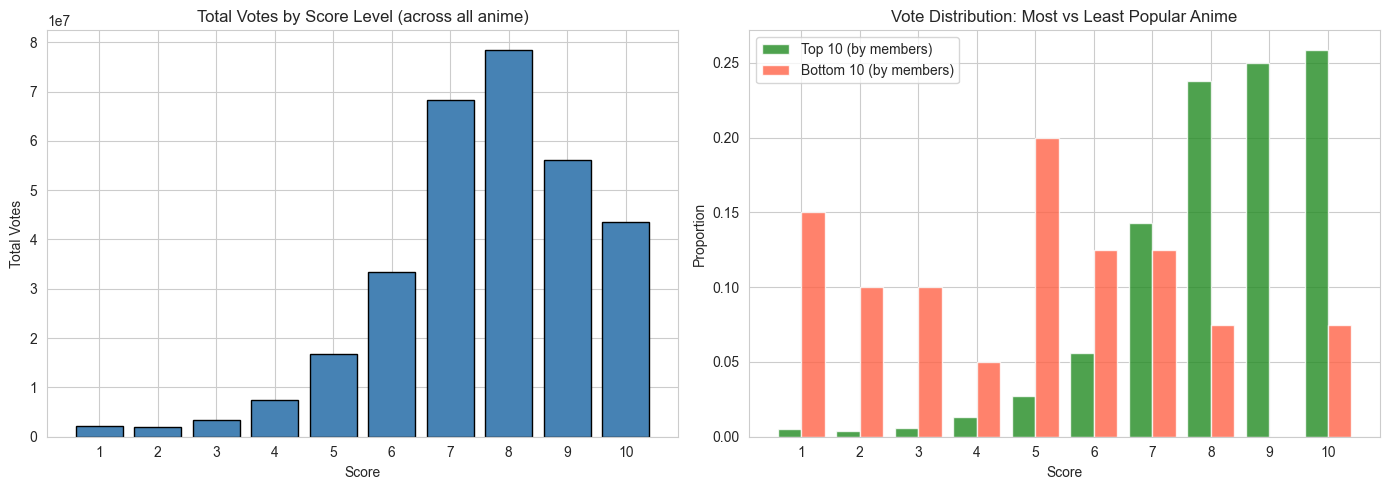

In [18]:
# Analyze the per-score vote columns
score_cols = [f'Score-{i}' for i in range(1, 11)]

# Convert score columns to numeric (may contain strings or NaN)
for col in score_cols:
    anime[col] = pd.to_numeric(anime[col], errors='coerce')

# Total votes per score bucket across all anime
total_votes = anime[score_cols].sum().values
score_labels = list(range(1, 11))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(score_labels, total_votes, color='steelblue', edgecolor='black')
axes[0].set_title('Total Votes by Score Level (across all anime)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Total Votes')
axes[0].set_xticks(score_labels)

# Proportion of each score for top 10 vs bottom 10 anime
top10 = anime.nlargest(10, 'Members')
bot10 = anime[anime['Members'] > 0].nsmallest(10, 'Members')

top10_dist = top10[score_cols].sum().values.astype(float)
bot10_dist = bot10[score_cols].sum().values.astype(float)
top10_dist = top10_dist / top10_dist.sum()
bot10_dist = bot10_dist / bot10_dist.sum()

x = np.arange(10)
axes[1].bar(x - 0.2, top10_dist, 0.4, label='Top 10 (by members)', color='forestgreen', alpha=0.8)
axes[1].bar(x + 0.2, bot10_dist, 0.4, label='Bottom 10 (by members)', color='tomato', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(score_labels)
axes[1].set_title('Vote Distribution: Most vs Least Popular Anime')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.9 Temporal Analysis (Premiered / Aired)

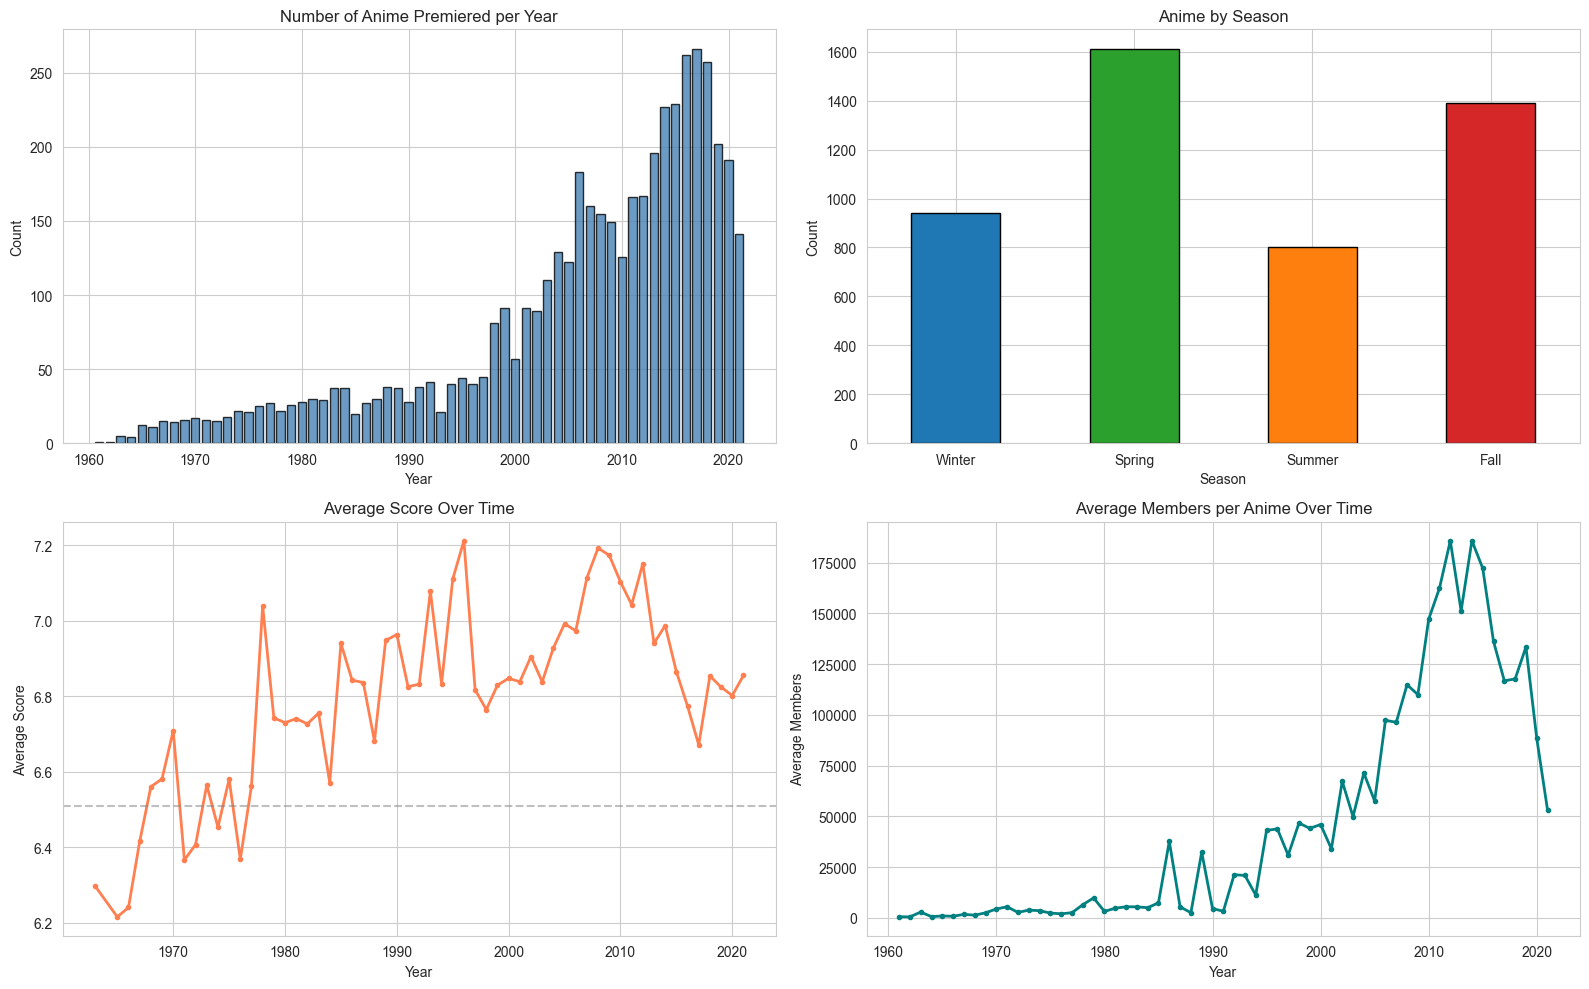

In [19]:
# Extract year and season from Premiered
anime['Premiered_Season'] = anime['Premiered'].str.extract(r'(Spring|Summer|Fall|Winter)')
anime['Premiered_Year'] = anime['Premiered'].str.extract(r'(\d{4})').astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Anime per year
year_counts = anime['Premiered_Year'].dropna().value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 1960]
axes[0, 0].bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Number of Anime Premiered per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')

# Season distribution
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = anime['Premiered_Season'].value_counts().reindex(season_order)
season_counts.plot(kind='bar', ax=axes[0, 1], color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black')
axes[0, 1].set_title('Anime by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Average score over time
yearly_score = anime.dropna(subset=['Premiered_Year', 'Score']).groupby('Premiered_Year')['Score'].mean()
yearly_score = yearly_score[yearly_score.index >= 1960]
axes[1, 0].plot(yearly_score.index, yearly_score.values, color='coral', linewidth=2, marker='o', markersize=3)
axes[1, 0].set_title('Average Score Over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Score')
axes[1, 0].axhline(anime['Score'].mean(), color='gray', linestyle='--', alpha=0.5)

# Average members over time
yearly_members = anime.dropna(subset=['Premiered_Year']).groupby('Premiered_Year')['Members'].mean()
yearly_members = yearly_members[yearly_members.index >= 1960]
axes[1, 1].plot(yearly_members.index, yearly_members.values, color='teal', linewidth=2, marker='o', markersize=3)
axes[1, 1].set_title('Average Members per Anime Over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Members')

plt.tight_layout()
plt.show()

### 2.10 Watching Status Breakdown (from anime.csv columns)

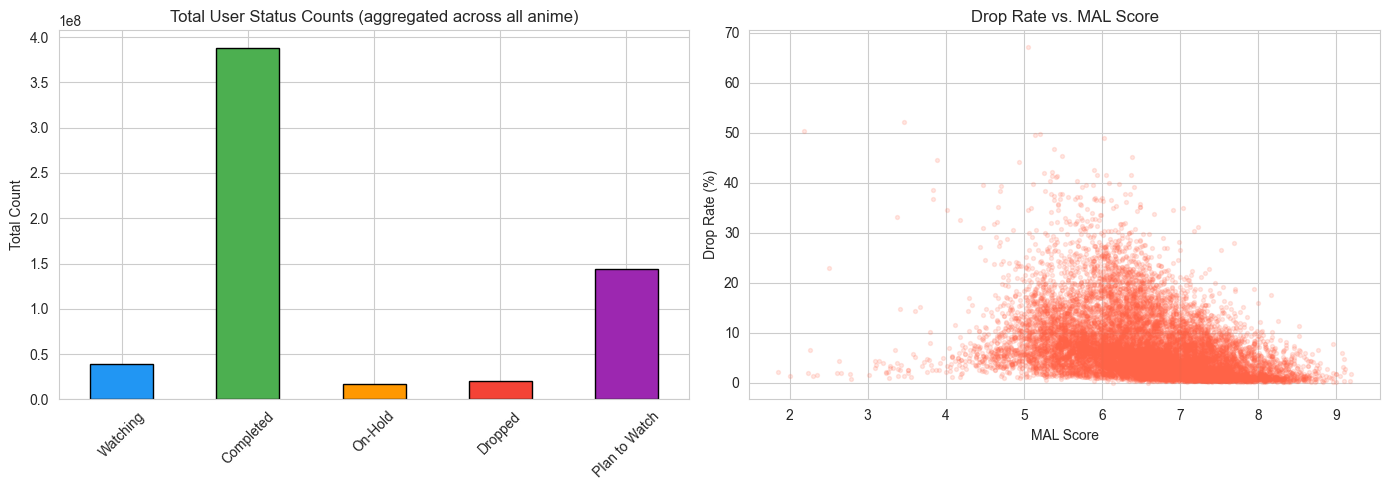


Correlation (Score vs Drop Rate): -0.350


In [20]:
# anime.csv has columns: Watching, Completed, On-Hold, Dropped, Plan to Watch
status_cols = ['Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch']
status_totals = anime[status_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_totals.plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0'], edgecolor='black')
axes[0].set_title('Total User Status Counts (aggregated across all anime)')
axes[0].set_ylabel('Total Count')
axes[0].tick_params(axis='x', rotation=45)

# Completion rate: Completed / (Completed + Dropped)
anime['completion_rate'] = anime['Completed'] / (anime['Completed'] + anime['Dropped']).replace(0, np.nan)
anime['drop_rate'] = anime['Dropped'] / (anime['Watching'] + anime['Completed'] + anime['On-Hold'] + anime['Dropped']).replace(0, np.nan)

scored_with_rates = anime.dropna(subset=['Score', 'drop_rate'])
axes[1].scatter(scored_with_rates['Score'], scored_with_rates['drop_rate'] * 100, alpha=0.15, s=8, color='tomato')
axes[1].set_title('Drop Rate vs. MAL Score')
axes[1].set_xlabel('MAL Score')
axes[1].set_ylabel('Drop Rate (%)')

plt.tight_layout()
plt.show()

print(f"\nCorrelation (Score vs Drop Rate): {scored_with_rates['Score'].corr(scored_with_rates['drop_rate']):.3f}")

### 2.11 Correlation Heatmap (Numeric Features)

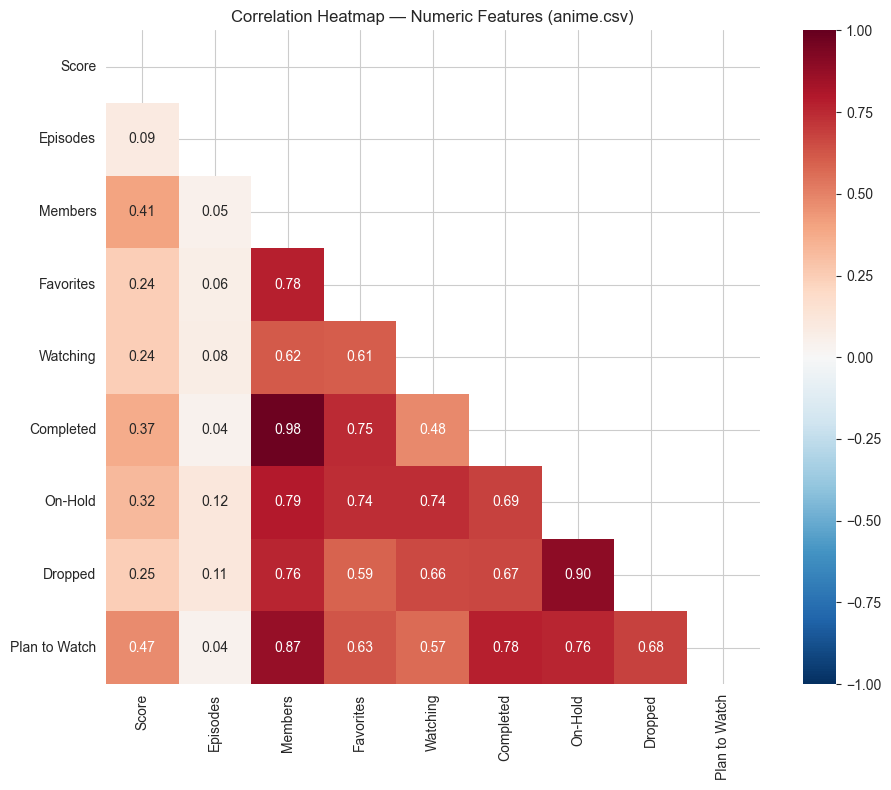

In [21]:
corr_cols = ['Score', 'Episodes', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch']
corr_matrix = anime[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features (anime.csv)')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing (anime.csv)

Based on the EDA findings above, we now clean and preprocess the anime dataset to prepare it for modeling. We work on a copy to preserve the original for reference.

### 3.1 Dropping Low-Information Columns

In [22]:
anime_processed = anime.copy()

# Japanese name & English name: not useful for modeling, and English name is 60% Unknown
anime_processed = anime_processed.drop(columns=["Japanese name", "English name"])
print("Dropped: Japanese name, English name")

# Premiered: 73% Unknown — we already extracted year/season into separate columns during EDA
anime_processed = anime_processed.drop(columns=["Premiered"])
print("Dropped: Premiered (73% Unknown; year/season already extracted)")

# Licensors: 78% Unknown — minimal information
anime_processed = anime_processed.drop(columns=["Licensors"])
print("Dropped: Licensors (78% Unknown)")

# Producers: 44% Unknown — users watch anime based on studios, not producers
anime_processed = anime_processed.drop(columns=["Producers"])
print("Dropped: Producers (44% Unknown; studios more relevant)")

print(f"\nRemaining columns: {anime_processed.shape[1]}")
print(anime_processed.columns.tolist())

Dropped: Japanese name, English name
Dropped: Premiered (73% Unknown; year/season already extracted)
Dropped: Licensors (78% Unknown)
Dropped: Producers (44% Unknown; studios more relevant)

Remaining columns: 35
['MAL_ID', 'Name', 'Score', 'Genres', 'Type', 'Episodes', 'Aired', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6', 'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'n_genres', 'Premiered_Season', 'Premiered_Year', 'completion_rate', 'drop_rate']


### 3.2 Genre Preprocessing

Hentai is excluded as it corresponds to explicit adult content outside the scope of the recommendation system. Unknown genres are also removed, and genres are one-hot encoded for modeling.

In [23]:
print(f"Before genre filtering: {len(anime_processed)} anime")

# Remove Hentai entries
anime_processed = anime_processed[~anime_processed["Genres"].str.contains("Hentai", na=False)]
print(f"After removing Hentai: {len(anime_processed)} anime")

# One-hot encode genres
genre_dummies = anime_processed["Genres"].str.get_dummies(", ")
anime_processed = pd.concat([anime_processed, genre_dummies], axis=1)

print(f"\nGenre columns created: {genre_dummies.shape[1]}")
print(f"Top 15 genres by frequency:")
print(genre_dummies.sum().sort_values(ascending=False).head(15))

# Remove entries with Unknown genre and drop the Unknown dummy column
if "Unknown" in anime_processed.columns:
    n_unknown = anime_processed["Unknown"].sum()
    anime_processed = anime_processed[anime_processed["Unknown"] == 0]
    anime_processed = anime_processed.drop(columns=["Unknown"])
    print(f"\nRemoved {n_unknown} entries with Unknown genre")

# Drop original Genres column (replaced by dummies)
anime_processed = anime_processed.drop(columns=["Genres"])
print(f"\nFinal shape after genre processing: {anime_processed.shape}")

Before genre filtering: 17562 anime
After removing Hentai: 16214 anime

Genre columns created: 42
Top 15 genres by frequency:
Comedy           5975
Action           3846
Fantasy          3202
Adventure        2942
Kids             2665
Drama            2589
Sci-Fi           2551
Music            2241
Shounen          2003
Slice of Life    1912
Romance          1852
School           1577
Supernatural     1410
Historical       1129
Mecha            1094
dtype: int64

Removed 63 entries with Unknown genre

Final shape after genre processing: (16151, 75)


### 3.3 Cleaning Numeric Columns (Score, Episodes, Type)

In [24]:
# Score: convert to numeric (Unknown -> NaN). We keep NaN scores — they can use implicit signals.
anime_processed["Score"] = pd.to_numeric(anime_processed["Score"], errors="coerce")
print(f"Score NaN count: {anime_processed['Score'].isna().sum()} ({anime_processed['Score'].isna().mean()*100:.1f}%)")
print("Keeping NaN scores — will use implicit data (watching status, episodes) for these entries.")

# Episodes: convert to numeric, drop entries where Unknown
anime_processed["Episodes"] = pd.to_numeric(anime_processed["Episodes"], errors="coerce")
n_ep_na = anime_processed["Episodes"].isna().sum()
anime_processed = anime_processed.dropna(subset=["Episodes"])
print(f"\nEpisodes: removed {n_ep_na} entries with Unknown episodes")

# Type: remove the few Unknown entries
n_type_unk = (anime_processed["Type"] == "Unknown").sum()
anime_processed = anime_processed[anime_processed["Type"] != "Unknown"]
print(f"Type: removed {n_type_unk} entries with Unknown type")

print(f"\nShape after cleaning: {anime_processed.shape}")

Score NaN count: 5075 (31.4%)
Keeping NaN scores — will use implicit data (watching status, episodes) for these entries.

Episodes: removed 474 entries with Unknown episodes
Type: removed 2 entries with Unknown type

Shape after cleaning: (15675, 75)


### 3.4 Ranked & Popularity Analysis

These columns are derived metrics — Ranked is ordered by Score, and Popularity is ordered by Members. We verify this and clean them.

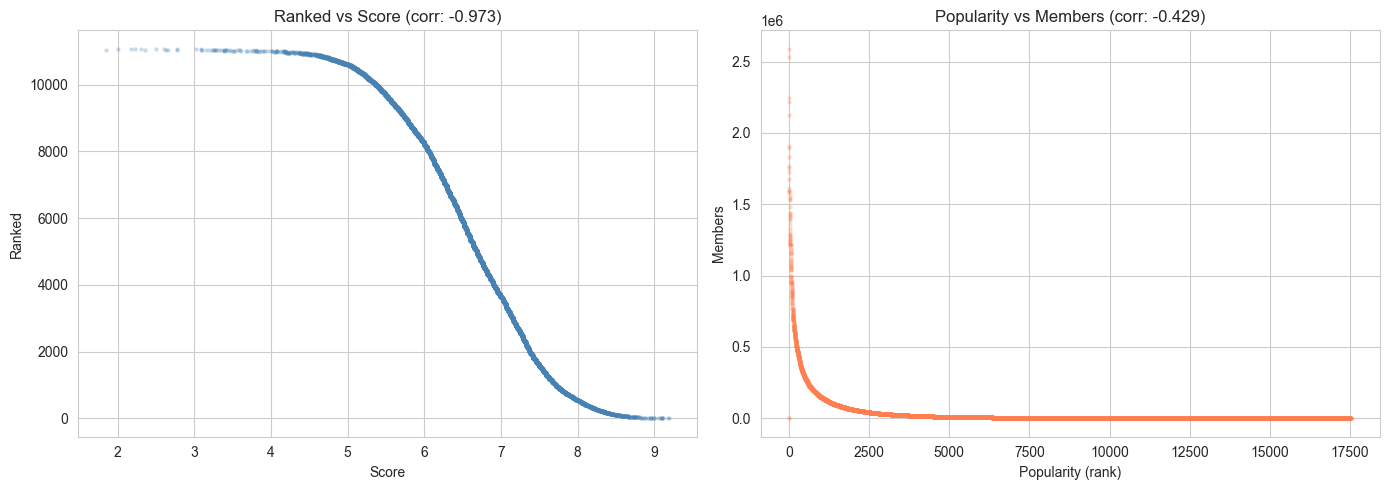

Removed 143 unranked entries
Confirmed: Ranked is derived from Score ordering, Popularity from Members ordering
Shape: (15532, 75)


In [25]:
# Ranked: clean the # prefix, convert to numeric, treat 0 as NA
anime_processed["Ranked"] = anime_processed["Ranked"].astype(str).str.replace("#", "", regex=False)
anime_processed["Ranked"] = pd.to_numeric(anime_processed["Ranked"], errors="coerce")
anime_processed["Ranked"] = anime_processed["Ranked"].where(anime_processed["Ranked"] != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ranked vs Score — verify they are inversely correlated
temp = anime_processed[["Ranked", "Score"]].dropna()
axes[0].scatter(temp["Score"], temp["Ranked"], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Ranked")
axes[0].set_title(f'Ranked vs Score (corr: {temp["Ranked"].corr(temp["Score"]):.3f})')

# Popularity vs Members — verify they are correlated
temp2 = anime_processed[["Popularity", "Members"]].dropna()
axes[1].scatter(temp2["Popularity"], temp2["Members"], alpha=0.2, s=5, color='coral')
axes[1].set_xlabel("Popularity (rank)")
axes[1].set_ylabel("Members")
axes[1].set_title(f'Popularity vs Members (corr: {temp2["Popularity"].corr(temp2["Members"]):.3f})')

plt.tight_layout()
plt.show()

# Popularity: treat 0 as NA (unranked entries)
anime_processed["Popularity"] = anime_processed["Popularity"].where(anime_processed["Popularity"] != 0)

# Remove entries with no Ranked value (very few, unranked anime)
n_unranked = anime_processed["Ranked"].isna().sum()
anime_processed = anime_processed.dropna(subset=["Ranked"])
print(f"Removed {n_unranked} unranked entries")
print(f"Confirmed: Ranked is derived from Score ordering, Popularity from Members ordering")
print(f"Shape: {anime_processed.shape}")

### 3.5 Source Grouping

Source has 16 categories, many with very few entries. We group them into the top categories plus "Other" to reduce cardinality.

In [26]:
# Replace "Unknown" Source with NaN
anime_processed["Source"] = anime_processed["Source"].replace("Unknown", pd.NA)

# Group rare sources into "Other"
top_sources = ["Original", "Manga", "Game", "Light novel", "Book"]
anime_processed["Source_grouped"] = anime_processed["Source"].apply(
    lambda x: x if pd.isna(x) or x in top_sources else "Other"
)
anime_processed = anime_processed.drop(columns=["Source"])

print("Source grouped distribution:")
print(anime_processed["Source_grouped"].value_counts())
print(f"\nNaN (originally Unknown): {anime_processed['Source_grouped'].isna().sum()}")

Source grouped distribution:
Original       4860
Manga          3365
Other          2415
Game            814
Light novel     693
Book            110
Name: Source_grouped, dtype: int64

NaN (originally Unknown): 3275


### 3.6 Feature Engineering: Favorites Ratio

Favorites and Members are highly correlated (as seen in 2.11). To capture relative user engagement beyond raw popularity, we create a normalized ratio.

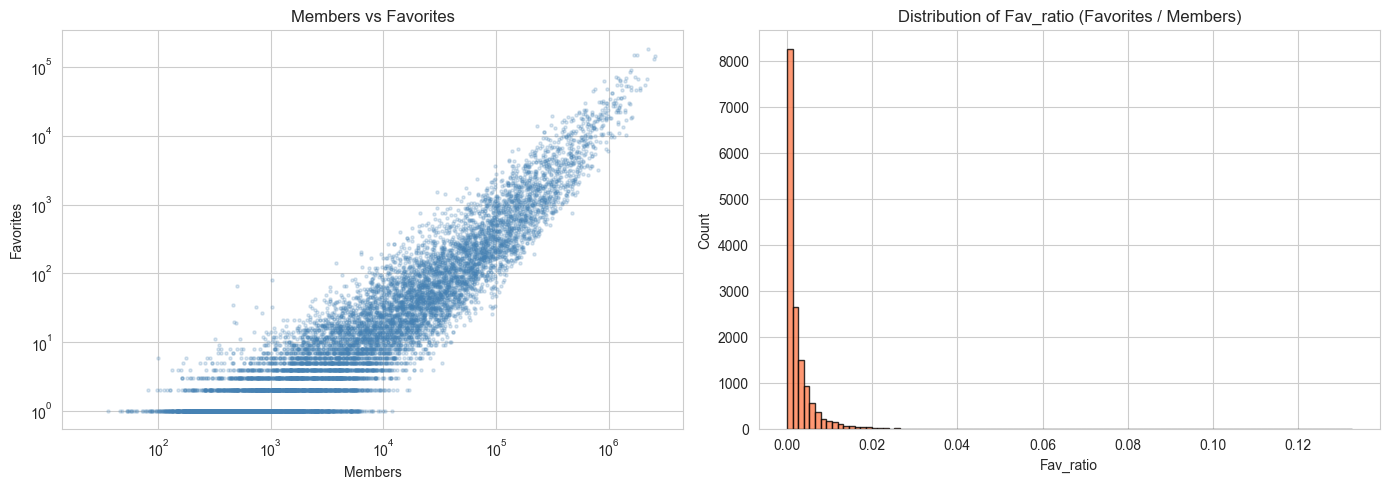

Fav_ratio stats:
count    15532.000000
mean         0.002714
std          0.005172
min          0.000000
25%          0.000000
50%          0.001137
75%          0.003210
max          0.132530
Name: Fav_ratio, dtype: float64

Top 10 anime by Fav_ratio (min 1000 members):
                                Name  Members  Favorites  Fav_ratio  Score
              Hunter x Hunter (2011)  1673924     147274   0.087981   9.10
                         Steins;Gate  1771162     148452   0.083816   9.11
    Fullmetal Alchemist: Brotherhood  2248456     183914   0.081796   9.19
                               Zinba     1018         80   0.078585   6.68
                Clannad: After Story   915885      62162   0.067871   8.96
                             Gintama   754607      48247   0.063937   8.96
                  Ishuzoku Reviewers   311653      19223   0.061681   7.58
             Neon Genesis Evangelion  1160651      71308   0.061438   8.32
Shingeki no Kyojin: The Final Season   733260      44

In [27]:
# Fav_ratio: proportion of members who favorited the anime
anime_processed["Fav_ratio"] = (anime_processed["Favorites"] / anime_processed["Members"]).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(anime_processed["Members"], anime_processed["Favorites"], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel("Members")
axes[0].set_ylabel("Favorites")
axes[0].set_title("Members vs Favorites")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[1].hist(anime_processed["Fav_ratio"], bins=100, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title("Distribution of Fav_ratio (Favorites / Members)")
axes[1].set_xlabel("Fav_ratio")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Fav_ratio stats:\n{anime_processed['Fav_ratio'].describe()}")
print(f"\nTop 10 anime by Fav_ratio (min 1000 members):")
popular = anime_processed[anime_processed["Members"] >= 1000]
print(popular.nlargest(10, "Fav_ratio")[["Name", "Members", "Favorites", "Fav_ratio", "Score"]].to_string(index=False))

### 3.7 Duplicate Names Check

In [28]:
# Check for duplicate anime names
dup_names = anime_processed["Name"].value_counts()
dup_names = dup_names[dup_names > 1]
print(f"Anime with duplicate names: {len(dup_names)}\n")

if len(dup_names) > 0:
    for name in dup_names.index[:5]:
        print(f'"{name}" appears {dup_names[name]} times:')
        print(anime_processed[anime_processed["Name"] == name][["MAL_ID", "Name", "Type", "Episodes", "Score"]].to_string(index=False))
        print()
    print("These are different entries (e.g., original anime vs OVA) sharing the same name — MAL_ID is unique, so no deduplication needed.")

Anime with duplicate names: 2

"Youkoso! Ecolo Shima" appears 2 times:
 MAL_ID                 Name Type  Episodes  Score
  35279 Youkoso! Ecolo Shima  OVA       1.0    NaN
  39143 Youkoso! Ecolo Shima  OVA       1.0    NaN

"Hinamatsuri" appears 2 times:
 MAL_ID        Name Type  Episodes  Score
  35102 Hinamatsuri  OVA       1.0   6.79
  36296 Hinamatsuri   TV      12.0   8.21

These are different entries (e.g., original anime vs OVA) sharing the same name — MAL_ID is unique, so no deduplication needed.


### 3.8 Preprocessing Summary

In [29]:
print(f"Original anime.csv shape: {anime.shape}")
print(f"Processed shape: {anime_processed.shape}")
print(f"Rows removed: {len(anime) - len(anime_processed)} ({(len(anime) - len(anime_processed))/len(anime)*100:.1f}%)")
print(f"\nColumns dropped: Japanese name, English name, Premiered, Licensors, Producers, Source, Genres")
print(f"Columns added: {genre_dummies.shape[1]-1} genre dummies, Source_grouped, Fav_ratio")
print(f"\nFinal column types:")
print(f"  Numeric: {anime_processed.select_dtypes(include='number').shape[1]}")
print(f"  Object/Categorical: {anime_processed.select_dtypes(include='object').shape[1]}")
print(f"\nProcessed DataFrame info:")
anime_processed.info()

Original anime.csv shape: (17562, 40)
Processed shape: (15532, 76)
Rows removed: 2030 (11.6%)

Columns dropped: Japanese name, English name, Premiered, Licensors, Producers, Source, Genres
Columns added: 41 genre dummies, Source_grouped, Fav_ratio

Final column types:
  Numeric: 68
  Object/Categorical: 8

Processed DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 15532 entries, 0 to 17556
Data columns (total 76 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MAL_ID            15532 non-null  int64  
 1   Name              15532 non-null  object 
 2   Score             10980 non-null  float64
 3   Type              15532 non-null  object 
 4   Episodes          15532 non-null  float64
 5   Aired             15532 non-null  object 
 6   Studios           15532 non-null  object 
 7   Duration          15532 non-null  object 
 8   Rating            15532 non-null  object 
 9   Ranked            15532 non-null  f

---
## 4. EDA on animelist.csv

Using the full-dataset statistics computed during loading and the 5,000-user sample for detailed visualizations.

### 4.1 Rating Distribution

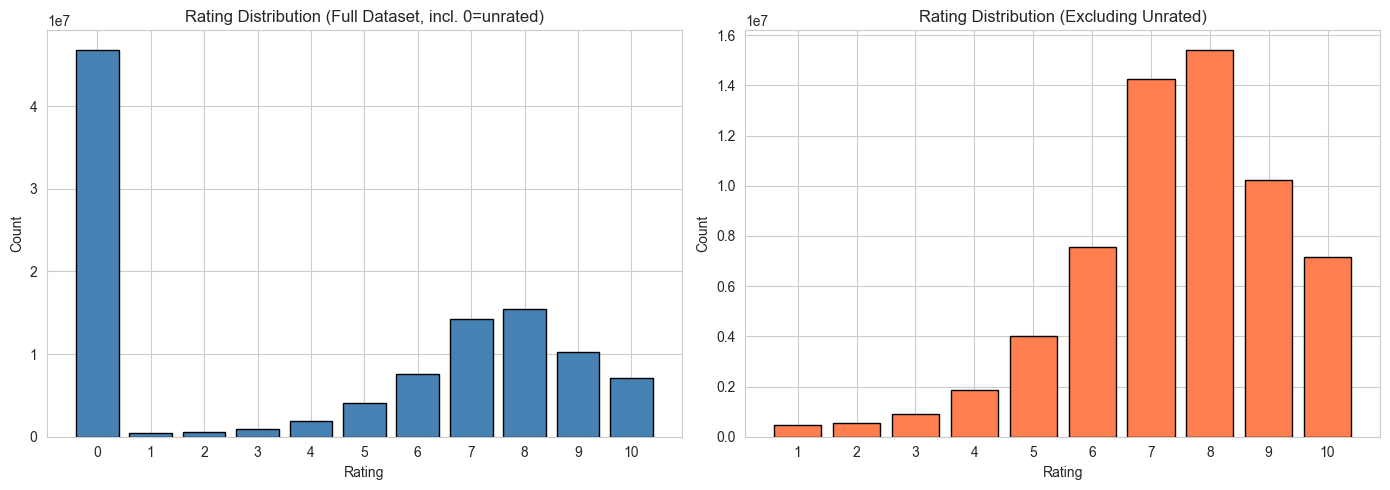

Rating 0 (unrated): 46,827,035 (42.9%)

Rated distribution (1-10):
  Rating  1:      480,688 (0.8%)
  Rating  2:      545,339 (0.9%)
  Rating  3:      905,700 (1.5%)
  Rating  4:    1,845,854 (3.0%)
  Rating  5:    4,029,645 (6.5%)
  Rating  6:    7,543,377 (12.1%)
  Rating  7:   14,244,633 (22.8%)
  Rating  8:   15,422,150 (24.7%)
  Rating  9:   10,235,934 (16.4%)
  Rating 10:    7,144,392 (11.4%)


In [30]:
# Rating distribution from full dataset (computed during loading)
rating_df = pd.Series(rating_counts).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All ratings including 0
axes[0].bar(rating_df.index, rating_df.values, color='steelblue', edgecolor='black')
axes[0].set_title('Rating Distribution (Full Dataset, incl. 0=unrated)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 11))

# Exclude 0 (unrated)
rated_only = rating_df[rating_df.index > 0]
axes[1].bar(rated_only.index, rated_only.values, color='coral', edgecolor='black')
axes[1].set_title('Rating Distribution (Excluding Unrated)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

print(f"Rating 0 (unrated): {rating_df.get(0, 0):,} ({rating_df.get(0, 0)/total_rows*100:.1f}%)")
print(f"\nRated distribution (1-10):")
for r in range(1, 11):
    cnt = rating_df.get(r, 0)
    print(f"  Rating {r:2d}: {cnt:>12,} ({cnt/rating_nonzero_count*100:.1f}%)")

### 4.2 Watching Status Distribution

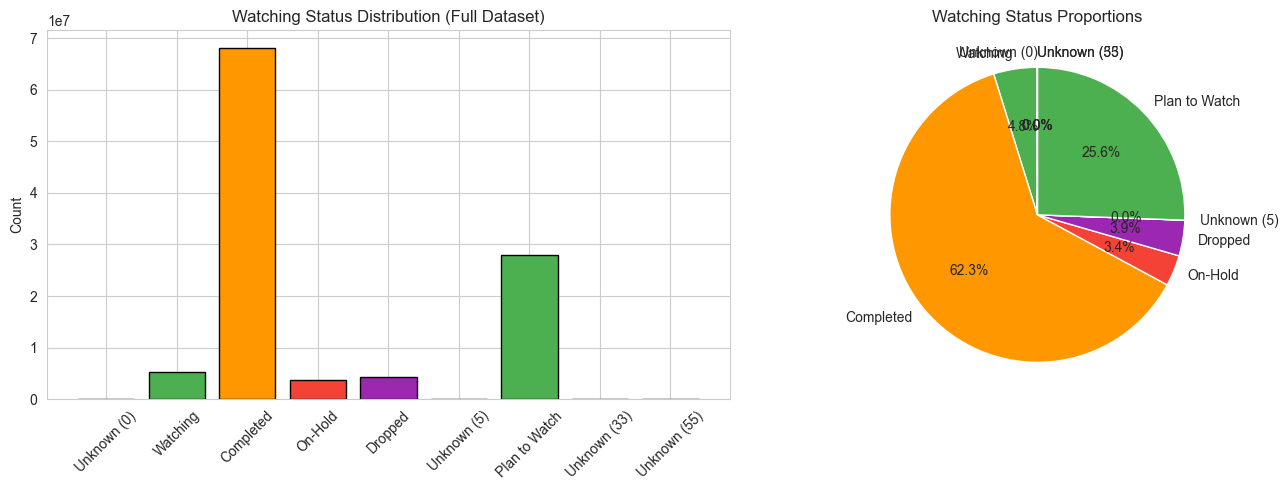

  Unknown (0):            531 (0.0%)
  Watching:      5,228,658 (4.8%)
  Completed:     68,089,751 (62.3%)
  On-Hold:      3,700,514 (3.4%)
  Dropped:      4,266,591 (3.9%)
  Unknown (5):              6 (0.0%)
  Plan to Watch:     27,938,693 (25.6%)
  Unknown (33):              2 (0.0%)
  Unknown (55):              1 (0.0%)


In [31]:
# Watching status: 1=Watching, 2=Completed, 3=On-Hold, 4=Dropped, 6=Plan to Watch
status_labels = {1: 'Watching', 2: 'Completed', 3: 'On-Hold', 4: 'Dropped', 6: 'Plan to Watch'}
status_df = pd.Series(status_counts).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_status = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
labels = [status_labels.get(k, f'Unknown ({k})') for k in status_df.index]

axes[0].bar(labels, status_df.values, color=colors_status[:len(labels)], edgecolor='black')
axes[0].set_title('Watching Status Distribution (Full Dataset)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(status_df.values, labels=labels, autopct='%1.1f%%', colors=colors_status[:len(labels)], startangle=90)
axes[1].set_title('Watching Status Proportions')

plt.tight_layout()
plt.show()

for k, v in status_df.items():
    print(f"  {status_labels.get(k, f'Unknown ({k})')}: {v:>14,} ({v/total_rows*100:.1f}%)")

### 4.3 User Activity Analysis

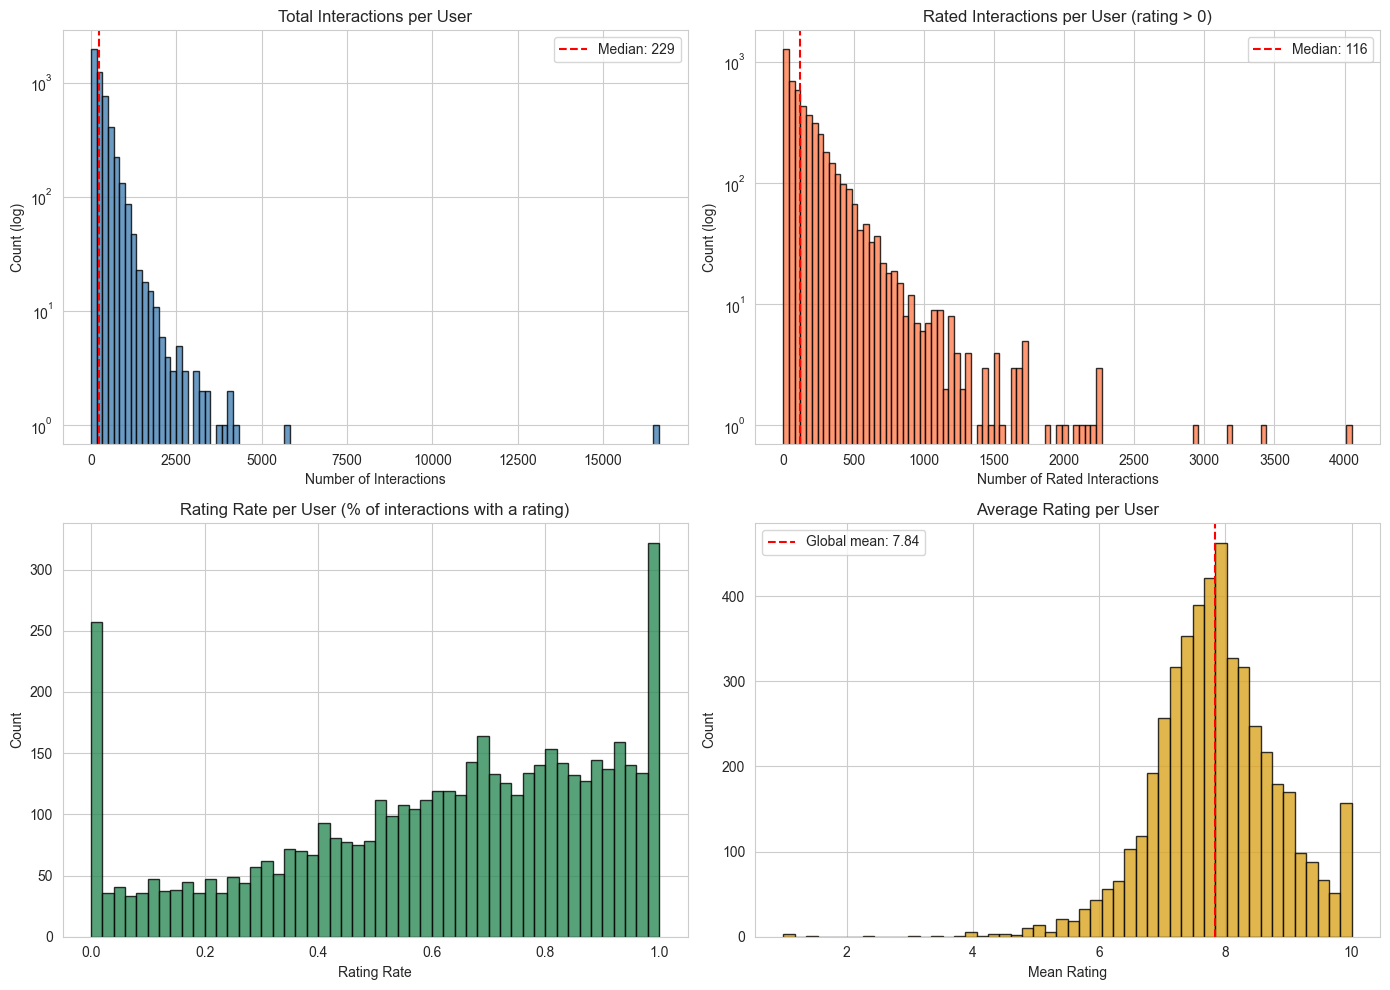

User activity statistics (from sample):
       total_interactions  rated_interactions  mean_rating
count             5000.00             5000.00      4821.00
mean               332.68              191.35         7.84
std                440.71              252.76         0.98
min                  1.00                0.00         1.00
25%                 94.00               39.00         7.26
50%                229.00              116.00         7.83
75%                432.25              251.00         8.42
max              16639.00             4050.00        10.00


In [32]:
# User activity from sample
user_stats = animelist_sample.groupby('user_id').agg(
    total_interactions=('anime_id', 'count'),
    rated_interactions=('rating', lambda x: (x > 0).sum()),
    mean_rating=('rating', lambda x: x[x > 0].mean() if (x > 0).any() else np.nan),
    unique_anime=('anime_id', 'nunique')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Interactions per user
axes[0, 0].hist(user_stats['total_interactions'], bins=100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Total Interactions per User')
axes[0, 0].set_xlabel('Number of Interactions')
axes[0, 0].set_ylabel('Count (log)')
axes[0, 0].axvline(user_stats['total_interactions'].median(), color='red', linestyle='--',
                    label=f"Median: {user_stats['total_interactions'].median():.0f}")
axes[0, 0].legend()

# Rated interactions per user
axes[0, 1].hist(user_stats['rated_interactions'], bins=100, color='coral', edgecolor='black', alpha=0.8)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Rated Interactions per User (rating > 0)')
axes[0, 1].set_xlabel('Number of Rated Interactions')
axes[0, 1].set_ylabel('Count (log)')
axes[0, 1].axvline(user_stats['rated_interactions'].median(), color='red', linestyle='--',
                    label=f"Median: {user_stats['rated_interactions'].median():.0f}")
axes[0, 1].legend()

# Rating rate per user
user_stats['rating_rate'] = user_stats['rated_interactions'] / user_stats['total_interactions']
axes[1, 0].hist(user_stats['rating_rate'], bins=50, color='seagreen', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Rating Rate per User (% of interactions with a rating)')
axes[1, 0].set_xlabel('Rating Rate')
axes[1, 0].set_ylabel('Count')

# Mean rating per user
axes[1, 1].hist(user_stats['mean_rating'].dropna(), bins=50, color='goldenrod', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Average Rating per User')
axes[1, 1].set_xlabel('Mean Rating')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(user_stats['mean_rating'].mean(), color='red', linestyle='--',
                    label=f"Global mean: {user_stats['mean_rating'].mean():.2f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"User activity statistics (from sample):")
print(user_stats[['total_interactions', 'rated_interactions', 'mean_rating']].describe().round(2))

### 4.4 Anime Popularity in animelist (interactions per anime)

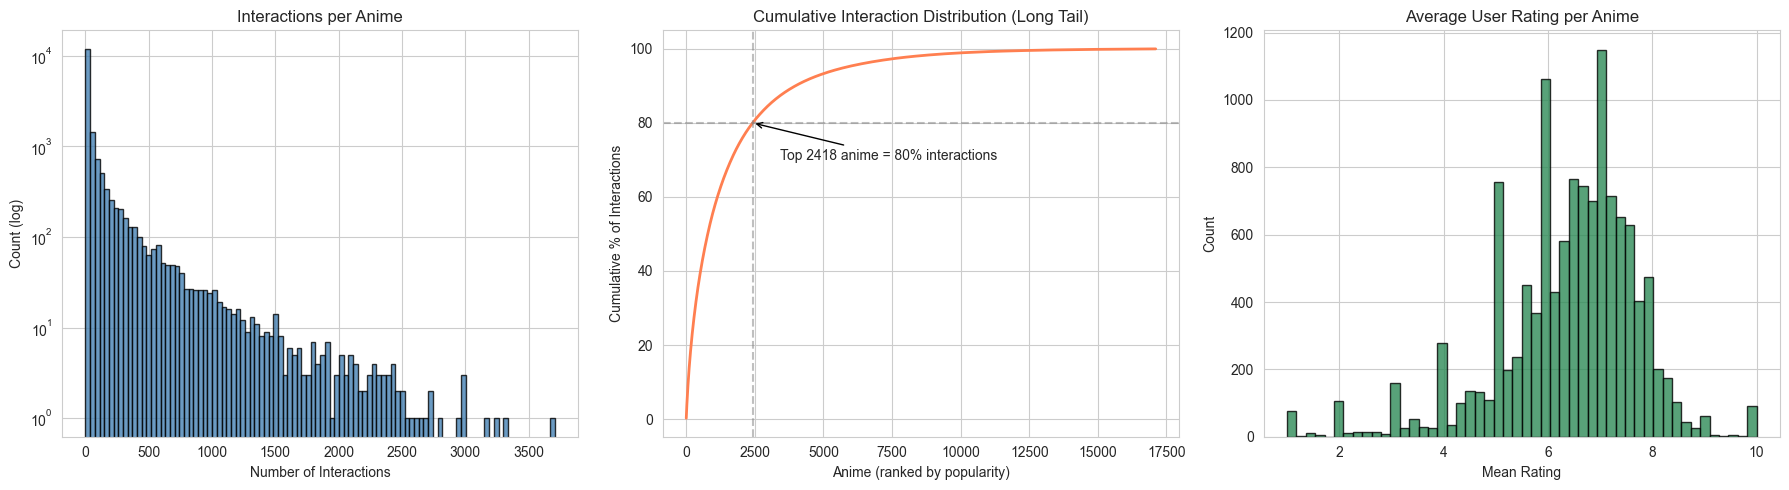


Anime popularity stats (from sample):
       n_interactions  n_ratings  mean_rating
count        17108.00   17108.00     12367.00
mean            97.23      55.92         6.37
std            257.44     169.12         1.36
min              1.00       0.00         1.00
25%              3.00       0.00         5.75
50%             11.00       4.00         6.58
75%             59.00      28.00         7.25
max           3707.00    3050.00        10.00

Anime with 0 ratings: 4741 (27.7%)


In [33]:
# Anime popularity from sample
anime_pop = animelist_sample.groupby('anime_id').agg(
    n_interactions=('user_id', 'count'),
    n_ratings=('rating', lambda x: (x > 0).sum()),
    mean_rating=('rating', lambda x: x[x > 0].mean() if (x > 0).any() else np.nan)
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Interactions per anime
axes[0].hist(anime_pop['n_interactions'], bins=100, color='steelblue', edgecolor='black', alpha=0.8, log=True)
axes[0].set_title('Interactions per Anime')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Count (log)')

# Long tail: cumulative distribution
sorted_pop = anime_pop['n_interactions'].sort_values(ascending=False).reset_index(drop=True)
cumulative = sorted_pop.cumsum() / sorted_pop.sum() * 100
axes[1].plot(range(len(cumulative)), cumulative, color='coral', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5)
n_80 = (cumulative <= 80).sum()
axes[1].axvline(n_80, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Cumulative Interaction Distribution (Long Tail)')
axes[1].set_xlabel('Anime (ranked by popularity)')
axes[1].set_ylabel('Cumulative % of Interactions')
axes[1].annotate(f'Top {n_80} anime = 80% interactions', xy=(n_80, 80), fontsize=10,
                xytext=(n_80 + 1000, 70), arrowprops=dict(arrowstyle='->', color='black'))

# Average user rating per anime
axes[2].hist(anime_pop['mean_rating'].dropna(), bins=50, color='seagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Average User Rating per Anime')
axes[2].set_xlabel('Mean Rating')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nAnime popularity stats (from sample):")
print(anime_pop[['n_interactions', 'n_ratings', 'mean_rating']].describe().round(2))
print(f"\nAnime with 0 ratings: {(anime_pop['n_ratings'] == 0).sum()} ({(anime_pop['n_ratings'] == 0).mean()*100:.1f}%)")

### 4.5 Rating Behavior by Watching Status

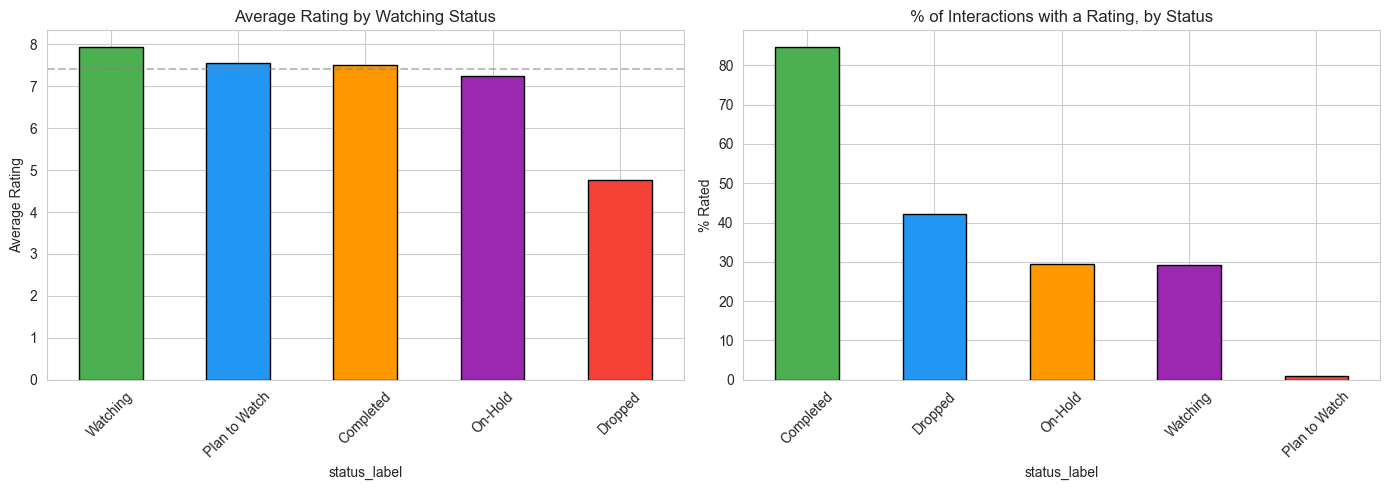

In [34]:
# Rating patterns by watching status
status_labels_map = {1: 'Watching', 2: 'Completed', 3: 'On-Hold', 4: 'Dropped', 6: 'Plan to Watch'}
animelist_sample['status_label'] = animelist_sample['watching_status'].map(status_labels_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average rating by status (excluding unrated)
rated_sample = animelist_sample[animelist_sample['rating'] > 0]
status_rating = rated_sample.groupby('status_label')['rating'].mean().sort_values(ascending=False)
status_rating.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336'], edgecolor='black')
axes[0].set_title('Average Rating by Watching Status')
axes[0].set_ylabel('Average Rating')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(rated_sample['rating'].mean(), color='gray', linestyle='--', alpha=0.5)

# % of interactions that are rated, by status
rate_by_status = animelist_sample.groupby('status_label')['rating'].apply(lambda x: (x > 0).mean() * 100)
rate_by_status.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336'], edgecolor='black')
axes[1].set_title('% of Interactions with a Rating, by Status')
axes[1].set_ylabel('% Rated')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.6 Watched Episodes Analysis

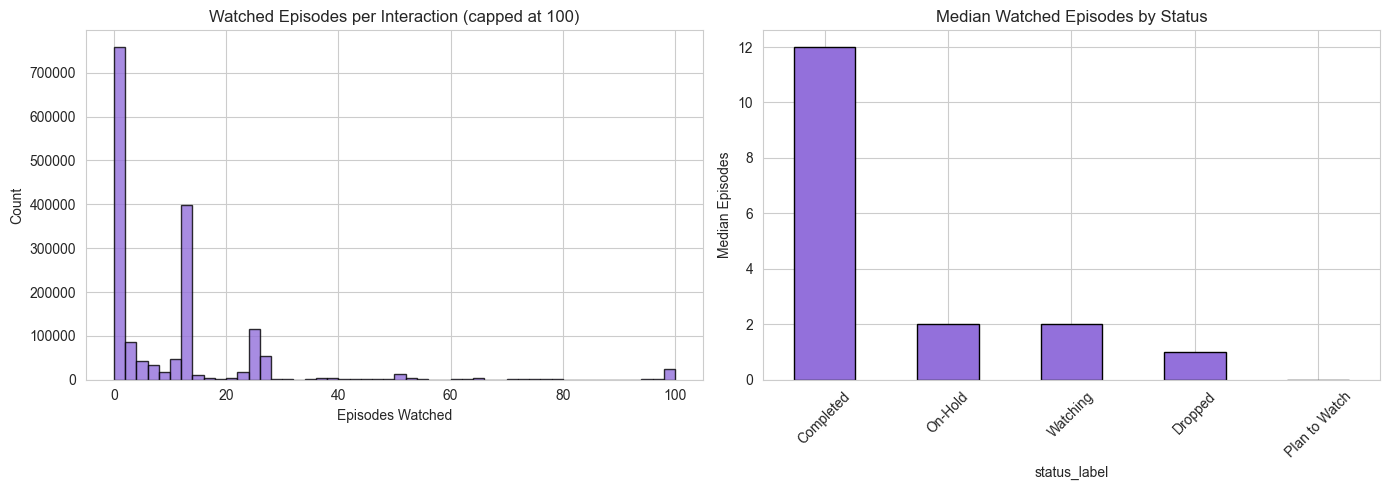

Watched episodes stats:
count    1.663415e+06
mean     1.205892e+01
std      7.919358e+01
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e+00
75%      1.200000e+01
max      6.553500e+04
Name: watched_episodes, dtype: float64


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Watched episodes distribution (capped at 100 for readability)
capped = animelist_sample['watched_episodes'].clip(upper=100)
axes[0].hist(capped, bins=50, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0].set_title('Watched Episodes per Interaction (capped at 100)')
axes[0].set_xlabel('Episodes Watched')
axes[0].set_ylabel('Count')

# Watched episodes by status
ep_by_status = animelist_sample.groupby('status_label')['watched_episodes'].median()
ep_by_status.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Median Watched Episodes by Status')
axes[1].set_ylabel('Median Episodes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Watched episodes stats:\n{animelist_sample['watched_episodes'].describe()}")

---
## 5. Combined Analysis (anime + animelist)

### 5.1 Merge and Coverage Check

In [36]:
# Merge sample with anime metadata
merged = animelist_sample.merge(anime[['MAL_ID', 'Name', 'Type', 'Genres', 'Score', 'Members', 'Episodes']],
                                 left_on='anime_id', right_on='MAL_ID', how='left')

anime_ids_in_list = set(animelist_sample['anime_id'].unique())
anime_ids_in_meta = set(anime['MAL_ID'].unique())

print(f"Anime IDs in animelist sample: {len(anime_ids_in_list):,}")
print(f"Anime IDs in anime.csv: {len(anime_ids_in_meta):,}")
print(f"Overlap: {len(anime_ids_in_list & anime_ids_in_meta):,}")
print(f"In animelist but NOT in anime.csv: {len(anime_ids_in_list - anime_ids_in_meta):,}")
print(f"In anime.csv but NOT in animelist sample: {len(anime_ids_in_meta - anime_ids_in_list):,}")
print(f"\nMerged shape: {merged.shape}")
print(f"Unmatched rows (no metadata): {merged['MAL_ID'].isna().sum():,} ({merged['MAL_ID'].isna().mean()*100:.2f}%)")

Anime IDs in animelist sample: 17,108
Anime IDs in anime.csv: 17,562
Overlap: 17,108
In animelist but NOT in anime.csv: 0
In anime.csv but NOT in animelist sample: 454

Merged shape: (1663415, 13)
Unmatched rows (no metadata): 0 (0.00%)


### 5.2 User Ratings vs. MAL Score

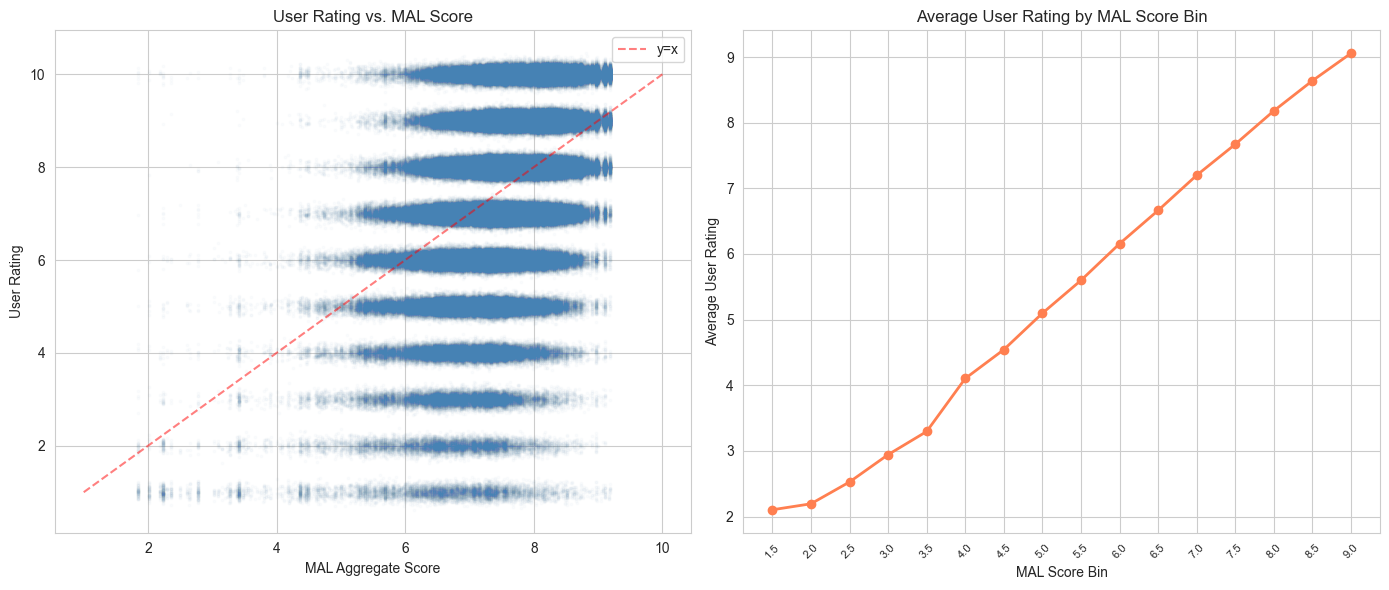

Correlation between MAL Score and user rating: 0.445


In [37]:
# Compare individual user ratings with MAL aggregate score
rated_merged = merged[(merged['rating'] > 0) & (merged['Score'].notna())].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: user rating vs MAL score (with jitter for visibility)
jitter = np.random.normal(0, 0.1, size=len(rated_merged))
axes[0].scatter(rated_merged['Score'], rated_merged['rating'] + jitter, alpha=0.02, s=3, color='steelblue')
axes[0].plot([1, 10], [1, 10], 'r--', alpha=0.5, label='y=x')
axes[0].set_xlabel('MAL Aggregate Score')
axes[0].set_ylabel('User Rating')
axes[0].set_title('User Rating vs. MAL Score')
axes[0].legend()

# Average user rating per MAL score bin
rated_merged['score_bin'] = pd.cut(rated_merged['Score'], bins=np.arange(1, 11, 0.5))
avg_by_bin = rated_merged.groupby('score_bin', observed=True)['rating'].mean()
axes[1].plot(range(len(avg_by_bin)), avg_by_bin.values, 'o-', color='coral', linewidth=2)
axes[1].set_xticks(range(len(avg_by_bin)))
axes[1].set_xticklabels([f'{x.left:.1f}' for x in avg_by_bin.index], rotation=45, fontsize=8)
axes[1].set_xlabel('MAL Score Bin')
axes[1].set_ylabel('Average User Rating')
axes[1].set_title('Average User Rating by MAL Score Bin')

plt.tight_layout()
plt.show()

corr = rated_merged['Score'].corr(rated_merged['rating'])
print(f"Correlation between MAL Score and user rating: {corr:.3f}")

### 5.3 Rating Patterns by Anime Type and Genre

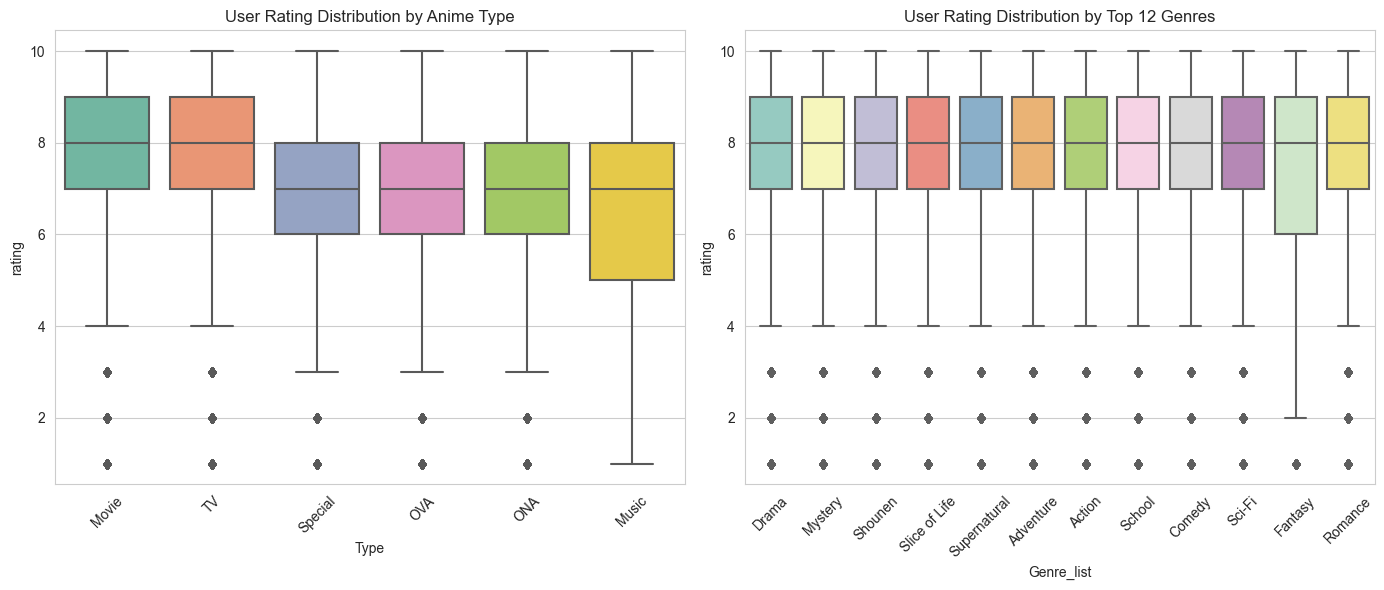

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# User ratings by anime type
type_order = rated_merged.groupby('Type')['rating'].mean().sort_values(ascending=False).index
sns.boxplot(data=rated_merged, x='Type', y='rating', order=type_order, ax=axes[0], palette='Set2')
axes[0].set_title('User Rating Distribution by Anime Type')
axes[0].tick_params(axis='x', rotation=45)

# User ratings by top genres
rated_with_genre = rated_merged.dropna(subset=['Genres']).copy()
rated_with_genre['Genre_list'] = rated_with_genre['Genres'].str.split(', ')
rated_exploded = rated_with_genre.explode('Genre_list')
rated_exploded['Genre_list'] = rated_exploded['Genre_list'].str.strip()

top_genres = rated_exploded['Genre_list'].value_counts().head(12).index
genre_data = rated_exploded[rated_exploded['Genre_list'].isin(top_genres)]
genre_order = genre_data.groupby('Genre_list')['rating'].mean().sort_values(ascending=False).index

sns.boxplot(data=genre_data, x='Genre_list', y='rating', order=genre_order, ax=axes[1], palette='Set3')
axes[1].set_title('User Rating Distribution by Top 12 Genres')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 5.4 Cold Start Analysis

=== Cold Start Analysis (from sample) ===

Users with fewer than N rated interactions:
  <   1 ratings: 179 users (3.6%)
  <   5 ratings: 427 users (8.5%)
  <  10 ratings: 575 users (11.5%)
  <  20 ratings: 808 users (16.2%)
  <  50 ratings: 1,437 users (28.7%)

Anime with fewer than N ratings:
  <   1 ratings: 4,741 anime (27.7%)
  <   5 ratings: 8,694 anime (50.8%)
  <  10 ratings: 10,507 anime (61.4%)
  <  20 ratings: 12,165 anime (71.1%)
  <  50 ratings: 13,809 anime (80.7%)


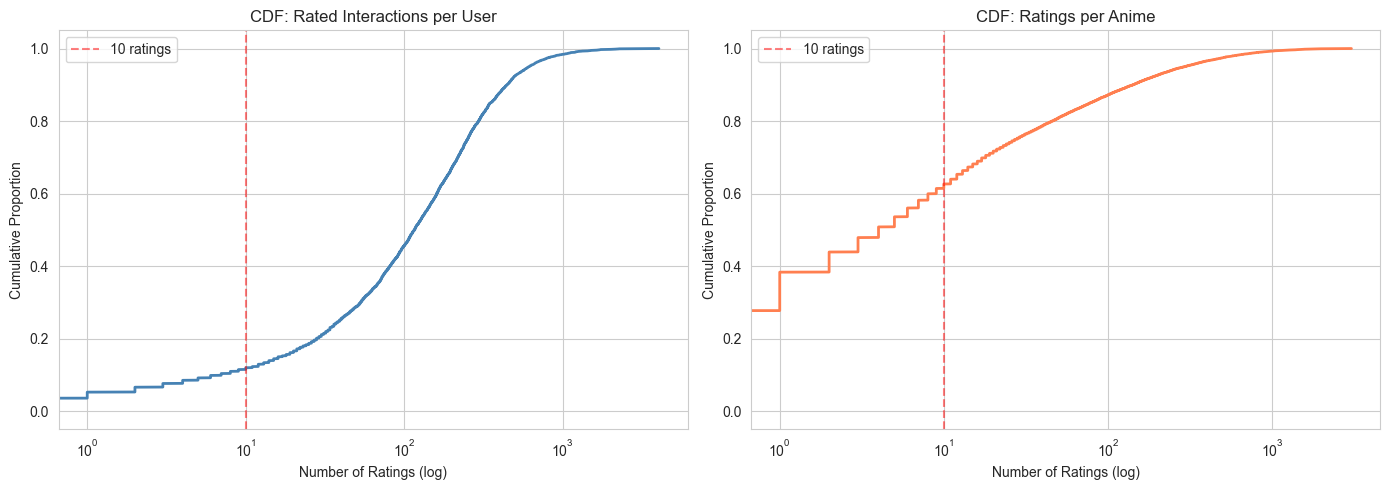

In [39]:
# Cold start: users/items with very few ratings
thresholds = [1, 5, 10, 20, 50]

print("=== Cold Start Analysis (from sample) ===\n")
print("Users with fewer than N rated interactions:")
for t in thresholds:
    n = (user_stats['rated_interactions'] < t).sum()
    print(f"  < {t:3d} ratings: {n:,} users ({n/len(user_stats)*100:.1f}%)")

print(f"\nAnime with fewer than N ratings:")
for t in thresholds:
    n = (anime_pop['n_ratings'] < t).sum()
    print(f"  < {t:3d} ratings: {n:,} anime ({n/len(anime_pop)*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_cdf = np.sort(user_stats['rated_interactions'].values)
axes[0].plot(user_cdf, np.linspace(0, 1, len(user_cdf)), color='steelblue', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_title('CDF: Rated Interactions per User')
axes[0].set_xlabel('Number of Ratings (log)')
axes[0].set_ylabel('Cumulative Proportion')
axes[0].axvline(10, color='red', linestyle='--', alpha=0.5, label='10 ratings')
axes[0].legend()

anime_cdf = np.sort(anime_pop['n_ratings'].values)
axes[1].plot(anime_cdf, np.linspace(0, 1, len(anime_cdf)), color='coral', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('CDF: Ratings per Anime')
axes[1].set_xlabel('Number of Ratings (log)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].axvline(10, color='red', linestyle='--', alpha=0.5, label='10 ratings')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5 User Rating Bias Analysis

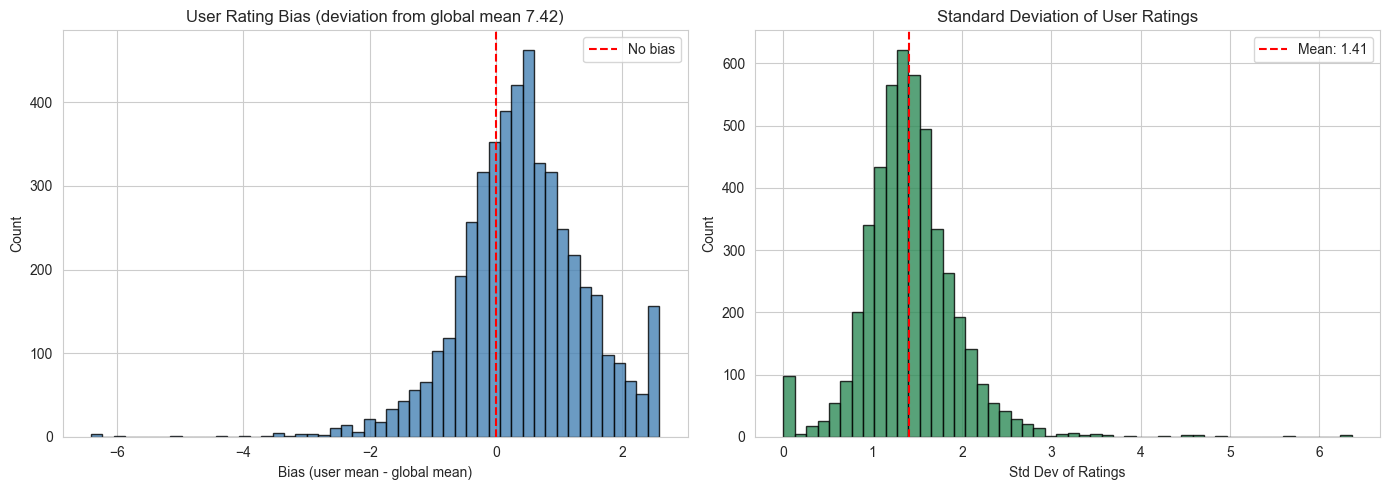

Users with positive bias (lenient): 3322 (66.4%)
Users with negative bias (strict): 1499 (30.0%)


In [40]:
# User bias: how much users deviate from the global mean
global_mean = rated_sample['rating'].mean()
user_stats['bias'] = user_stats['mean_rating'] - global_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_stats['bias'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', label='No bias')
axes[0].set_title(f'User Rating Bias (deviation from global mean {global_mean:.2f})')
axes[0].set_xlabel('Bias (user mean - global mean)')
axes[0].set_ylabel('Count')
axes[0].legend()

# User std dev of ratings
user_std = animelist_sample[animelist_sample['rating'] > 0].groupby('user_id')['rating'].std()
axes[1].hist(user_std.dropna(), bins=50, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Standard Deviation of User Ratings')
axes[1].set_xlabel('Std Dev of Ratings')
axes[1].set_ylabel('Count')
axes[1].axvline(user_std.mean(), color='red', linestyle='--', label=f'Mean: {user_std.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Users with positive bias (lenient): {(user_stats['bias'] > 0).sum()} ({(user_stats['bias'] > 0).mean()*100:.1f}%)")
print(f"Users with negative bias (strict): {(user_stats['bias'] < 0).sum()} ({(user_stats['bias'] < 0).mean()*100:.1f}%)")

---
## 6. Preprocessing animelist.csv

The animelist has ~109M rows. We clean it via chunked processing: remove invalid watching statuses, separate explicit ratings from implicit-only interactions, and apply cold-start filtering to remove users/anime with too few ratings for collaborative filtering.

### 6.1 Clean Interactions (chunked)

In [41]:
# Valid watching statuses: 1=Watching, 2=Completed, 3=On-Hold, 4=Dropped, 6=Plan to Watch
valid_statuses = {1, 2, 3, 4, 6}

# Only keep anime IDs that exist in our processed anime dataset
valid_anime_ids = set(anime_processed["MAL_ID"].values)

chunk_size = 5_000_000
clean_chunks = []
rows_before = 0
rows_invalid_status = 0
rows_no_anime_match = 0

for chunk in pd.read_csv('animelist.csv', chunksize=chunk_size):
    rows_before += len(chunk)
    
    # Remove invalid watching statuses (0, 5, 33, 55 — noise)
    valid_mask = chunk['watching_status'].isin(valid_statuses)
    rows_invalid_status += (~valid_mask).sum()
    chunk = chunk[valid_mask]
    
    # Only keep interactions for anime that survived preprocessing
    anime_mask = chunk['anime_id'].isin(valid_anime_ids)
    rows_no_anime_match += (~anime_mask).sum()
    chunk = chunk[anime_mask]
    
    clean_chunks.append(chunk)

animelist_clean = pd.concat(clean_chunks, ignore_index=True)

print(f"Original rows: {rows_before:,}")
print(f"Removed — invalid status: {rows_invalid_status:,}")
print(f"Removed — anime not in processed set: {rows_no_anime_match:,}")
print(f"Clean rows: {len(animelist_clean):,} ({len(animelist_clean)/rows_before*100:.1f}%)")
print(f"\nClean dataset shape: {animelist_clean.shape}")
print(f"Unique users: {animelist_clean['user_id'].nunique():,}")
print(f"Unique anime: {animelist_clean['anime_id'].nunique():,}")

Original rows: 109,224,747
Removed — invalid status: 540
Removed — anime not in processed set: 3,274,232
Clean rows: 105,949,975 (97.0%)

Clean dataset shape: (105949975, 5)
Unique users: 325,049
Unique anime: 15,532


### 6.2 Add Status Labels & Separate Explicit vs Implicit

In [42]:
# Add human-readable status labels
status_map = {1: 'Watching', 2: 'Completed', 3: 'On-Hold', 4: 'Dropped', 6: 'Plan to Watch'}
animelist_clean['status_label'] = animelist_clean['watching_status'].map(status_map)

# Separate explicit (rated) vs implicit-only (unrated) interactions
explicit = animelist_clean[animelist_clean['rating'] > 0].copy()
implicit_only = animelist_clean[animelist_clean['rating'] == 0].copy()

print(f"Explicit interactions (rating > 0): {len(explicit):,} ({len(explicit)/len(animelist_clean)*100:.1f}%)")
print(f"Implicit-only interactions (rating = 0): {len(implicit_only):,} ({len(implicit_only)/len(animelist_clean)*100:.1f}%)")
print(f"\nExplicit rating stats:\n{explicit['rating'].describe()}")
print(f"\nStatus breakdown in explicit set:")
print(explicit['status_label'].value_counts())

Explicit interactions (rating > 0): 61,138,899 (57.7%)
Implicit-only interactions (rating = 0): 44,811,076 (42.3%)

Explicit rating stats:
count    6.113890e+07
mean     7.449882e+00
std      1.752018e+00
min      1.000000e+00
25%      7.000000e+00
50%      8.000000e+00
75%      9.000000e+00
max      1.000000e+01
Name: rating, dtype: float64

Status breakdown in explicit set:
Completed        56624619
Dropped           1893822
Watching          1357103
On-Hold            998758
Plan to Watch      264597
Name: status_label, dtype: int64


### 6.3 Cold-Start Filtering

Users and anime with very few ratings produce unreliable signals for collaborative filtering. We apply minimum thresholds to create a filtered dataset while preserving the full clean set for content-based and hybrid approaches.

In [43]:
MIN_USER_RATINGS = 5
MIN_ANIME_RATINGS = 5

# Count ratings per user and per anime (explicit only)
user_rating_counts = explicit.groupby('user_id').size()
anime_rating_counts = explicit.groupby('anime_id').size()

# Filter iteratively until stable (removing users can make anime fall below threshold and vice versa)
explicit_filtered = explicit.copy()
prev_len = 0
iteration = 0

while len(explicit_filtered) != prev_len:
    prev_len = len(explicit_filtered)
    iteration += 1
    
    # Filter users
    user_counts = explicit_filtered.groupby('user_id').size()
    valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
    explicit_filtered = explicit_filtered[explicit_filtered['user_id'].isin(valid_users)]
    
    # Filter anime
    anime_counts = explicit_filtered.groupby('anime_id').size()
    valid_anime = anime_counts[anime_counts >= MIN_ANIME_RATINGS].index
    explicit_filtered = explicit_filtered[explicit_filtered['anime_id'].isin(valid_anime)]
    
    print(f"Iteration {iteration}: {len(explicit_filtered):,} interactions, "
          f"{explicit_filtered['user_id'].nunique():,} users, "
          f"{explicit_filtered['anime_id'].nunique():,} anime")

print(f"\n--- Cold-Start Filtering Summary ---")
print(f"Before: {len(explicit):,} interactions | {explicit['user_id'].nunique():,} users | {explicit['anime_id'].nunique():,} anime")
print(f"After:  {len(explicit_filtered):,} interactions | {explicit_filtered['user_id'].nunique():,} users | {explicit_filtered['anime_id'].nunique():,} anime")
print(f"Removed: {len(explicit) - len(explicit_filtered):,} interactions ({(len(explicit) - len(explicit_filtered))/len(explicit)*100:.1f}%)")

Iteration 1: 61,103,354 interactions, 297,095 users, 15,168 anime
Iteration 2: 61,103,354 interactions, 297,095 users, 15,168 anime

--- Cold-Start Filtering Summary ---
Before: 61,138,899 interactions | 312,840 users | 15,518 anime
After:  61,103,354 interactions | 297,095 users | 15,168 anime
Removed: 35,545 interactions (0.1%)


### 6.4 Export Clean Datasets

We export the cleaned datasets for the ML team to use directly:
- `anime_processed.csv` — cleaned anime metadata with genre dummies and engineered features
- `animelist_clean.csv` — full cleaned interaction log (all valid interactions, before filtering/splitting)
- `explicit_ratings.csv` — all explicit ratings (rating > 0), cleaned and cold-start filtered
- `implicit_interactions.csv` — implicit-only interactions (rating = 0) for implicit feedback models

In [44]:
import os

output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

# 1. Anime metadata (cleaned, with genre dummies and engineered features)
anime_processed.to_csv(f"{output_dir}/anime_processed.csv", index=False)
print(f"Saved anime_processed.csv — {anime_processed.shape}")

# 2. Full cleaned interaction log (all valid interactions, before filtering)
animelist_clean.to_csv(f"{output_dir}/animelist_clean.csv", index=False)
print(f"Saved animelist_clean.csv — {animelist_clean.shape}")

# 3. Explicit ratings (cold-start filtered, ready for modeling)
explicit_filtered.to_csv(f"{output_dir}/explicit_ratings.csv", index=False)
print(f"Saved explicit_ratings.csv — {explicit_filtered.shape}")

# 4. Implicit interactions (unrated, for implicit feedback models)
implicit_only.to_csv(f"{output_dir}/implicit_interactions.csv", index=False)
print(f"Saved implicit_interactions.csv — {implicit_only.shape}")

print(f"\nAll files saved to '{output_dir}/':")
for f in sorted(os.listdir(output_dir)):
    size_mb = os.path.getsize(f"{output_dir}/{f}") / 1024 / 1024
    print(f"  {f:30s} {size_mb:>8.1f} MB")



Saved anime_processed.csv — (15532, 76)
Saved animelist_clean.csv — (105949975, 6)
Saved explicit_ratings.csv — (61103354, 6)
Saved implicit_interactions.csv — (44811076, 6)

All files saved to 'processed_data/':
  anime_processed.csv                 5.2 MB
  animelist_clean.csv              2972.4 MB
  explicit_ratings.csv             1676.3 MB
  implicit_interactions.csv        1295.1 MB


---
## 7. Key Findings & Implications for Recommendation System

### Data Overview
| Metric | Value |
|--------|-------|
| Total anime (raw) | ~17,562 |
| Anime after preprocessing | ~15,532 |
| Total users | ~325K+ |
| Total interactions (raw) | ~109M |
| Explicit ratings (after cleaning) | ~62M |
| User-item matrix sparsity | ~98%+ |

### Key Findings

**anime.csv:**
1. **Type distribution**: TV anime dominate, followed by OVA and Movie. TV shows also tend to have the highest scores.
2. **Scores are left-skewed**: Most anime score between 5-8 on MAL, with a mean around 6.5. Very few anime are rated below 3.
3. **Genre landscape**: Comedy, Action, and Music are the most common genres. Thriller and Josei tend to have higher average scores despite being rarer.
4. **Popularity is extremely long-tailed**: A small fraction of anime account for the vast majority of community members/engagement.
5. **Temporal trends**: Anime production has grown dramatically since 2000. Average scores have been relatively stable over time.
6. **Drop rate correlates with score**: Lower-scored anime are more likely to be dropped (correlation: -0.35).
7. **Missing values**: Many columns use "Unknown" placeholders — Licensors (78%), Premiered (73%), English name (60%), Producers (44%).
8. **Ranked and Popularity are derived**: Ranked is Score ordering; Popularity is Members ordering.

**Data Preprocessing:**
- Dropped 7 low-information columns; added ~41 genre dummies, Source_grouped, and Fav_ratio
- Removed Hentai entries and Unknown genres for cleaner modeling
- Final processed dataset retains ~88% of original entries with improved feature quality

**animelist.csv:**
1. **Massive implicit feedback**: 42.9% of interactions have rating=0 (unrated), providing implicit signals through watching status and episodes watched.
2. **Rating distribution is positively skewed**: Ratings 8 and 7 dominate (24.7% and 22.8%), suggesting users tend to rate anime they enjoy.
3. **Completed anime dominate**: 62.3% of interactions are Completed status, followed by Plan to Watch (25.6%).
4. **User activity is highly variable**: Cold-start filtering is essential — many users/anime have very few ratings.
5. **High sparsity**: The user-item matrix is 98.09% sparse (98.91% for rated-only interactions).

### Datasets Delivered
| File | Description |
|------|-------------|
| `anime_processed.csv` | Cleaned anime metadata with genre dummies, Source_grouped, Fav_ratio |
| `animelist_clean.csv` | Full cleaned interaction log (~100M rows); generated locally only, not in repo |
| `explicit_ratings.csv` | Cold-start filtered explicit ratings (rating > 0, min 5 per user/anime) |
| `implicit_interactions.csv` | Unrated interactions for implicit feedback models |

### Implications for Recommender System Design
- **Collaborative filtering** is viable given the large number of rated interactions, but the high sparsity suggests **matrix factorization** will outperform memory-based approaches.
- **Content-based filtering** can leverage the rich metadata (41 genre dummies, type, source, studio) to address the cold-start problem.
- The large number of **unrated interactions** (watching status, episodes watched) can serve as **implicit feedback**.
- **User bias normalization** will be important as 66% of users rate above the global mean.
- The **long-tail distribution** means a good recommender should balance popular items with niche recommendations.
- **Hybrid approaches** combining collaborative and content-based methods are well-suited for this dataset.